Esta es una pregunta metodológica crucial y la respuesta corta es: **Sí, tiene un sentido profundo, pero bajo una lógica muy diferente a la del Machine Learning tradicional.** 

De hecho, en la econometría y el análisis estadístico de series temporales, combinar el **Criterio de Información de Akaike Corregido (AICc)** con una partición **Train-Test (Validación Cruzada Cronológica)** es la estrategia más robusta posible para blindar tu tesis.



Aquí te explico analíticamente por qué se complementan en lugar de estorbarse:




# 1. El AICc mide el ajuste local; el Test mide la generalización temporal

El AICc y la partición Train-Test operan en dos dimensiones estadísticas distintas:

* **El AICc es una métrica *In-Sample* (dentro de la muestra):** Su ecuación matemática es:

$$\text{AICc} = \text{AIC} + \frac{2k(k + 1)}{n - k - 1}$$





Donde $k$ es el número de parámetros y $n$ es el tamaño de la muestra. El AICc estima cuánta información (entropía de Kullback-Leibler) se pierde **dentro del conjunto de entrenamiento**. 

Su trabajo es evitar que el modelo agregue demasiados rezagos ordinarios o exógenos que solo memoricen el ruido pasado.


* **El conjunto de Testeo es una métrica *Out-of-Sample* (fuera de la muestra):** Mide la capacidad del modelo para viajar en la dirección de la flecha del tiempo y predecir semanas que jamás vio.



**¿Por qué combinarlos?** Un modelo puede tener el AICc más bajo del mundo en el entrenamiento (indicando un ajuste matemático óptimo y parsimonioso), pero colapsar por completo en el futuro si la dinámica epidemiológica sufrió un cambio estructural. El conjunto de testeo es tu "auditoría de la vida real".

---



### 2. El peligro del "Data Leakage" (Fuga de Datos) estacional

Si decidieras **no** dividir el dataset y usar el 100% de los datos para buscar los parámetros con AICc, estarías cometiendo un error metodológico grave debido a la naturaleza de tu modelo $\text{SARIMAX}(2,1,1)\times(0,1,0)_{52}$.



Al incluir un rezago de 52 semanas, el modelo aprende la estructura de los brotes anuales. Si el algoritmo de búsqueda (`auto_arima`) evalúa el AICc usando absolutamente todos los datos, elegirá parámetros alterados por el último año de registros. Al hacer esto, no tendrías ninguna forma matemática de probar si tu modelo realmente predice o si simplemente está "copiando y pegando" el ciclo anual que ya conoce. Separar un 5% o 10% de testeo garantiza que evalúes al modelo en un escenario de ceguera real.

---



### 3. La regla de oro en series temporales: El enfoque jerárquico

En la práctica científica, estos dos conceptos se estructuran como un filtro de dos etapas:

```
[ Dataset Total ] ---> Separación Cronológica ---> [ Train (95%) ] y [ Test (5%) ]
                                                          |
                                          Ajuste con auto_arima (AICc)
                                                          |
                                          (Selecciona el mejor p, d, q)
                                                          |
                                           Validación Externa (MAE)
                                          (Evalúa predicción sobre Test)

```



1. **Fase de Selección (AICc):** Usas el conjunto de **Train** para que `auto_arima` compita internamente entre cientos de combinaciones de $(p,d,q)$. El AICc actúa como el juez interno que selecciona la estructura más equilibrada.
2. **Fase de Validación (MAE en Test):** Una vez congelada la estructura ganadora, la pones a prueba en el conjunto de **Test**. Si el MAE de testeo se mantiene controlado y cercano al de entrenamiento, tu modelo está listo para ser publicado en tu tesis con total validez científica.



# En conclusión

Tiene todo el sentido del mundo. El **AICc** encuentra el mejor modelo matemáticamente posible con los datos del pasado (**Train**), y la división **Train-Test** demuestra si ese modelo matemático ideal sigue siendo útil para predecir el futuro (**Test**).

Aquí tienes el script de Python completo que consolida todo el proceso metodológico bajo este enfoque jerárquico.



Tal como lo discutimos, el script divide cronológicamente el dataset original **sin rezagos** en los entornos de entrenamiento y testeo solicitados (**95-5**, **96-4**, **97-3**). 

En cada una de las interaciones, utiliza el conjunto de **Train** para alimentar el algoritmo `auto_arima` y buscar, mediante el criterio **AICc**, los mejores parámetros ordinarios $(p, d, q)$ de manera local. 

Posteriormente, inyecta esa estructura en el modelo formal `SARIMAX` para entrenarlo y medir su error absoluto medio (**MAE**) tanto dentro de la muestra (*In-Sample*) como fuera de ella (*Out-of-Sample*), generando finalmente la matriz de gráficos comparativos.

# Script Completo: División Cronológica, Selección por AICc y Evaluación MAE



[INFO] Cargando espacio muestral desde:
C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\1_raw_meteo_epi_con_y_sin_rezagos_escalados\1_datos_meteo_epi_sin_rezagos_escalados.xlsx
[INFO] Tamaño original del dataset: 261 semanas.
[INFO] Variables regresoras exógenas detectadas: ['año', 'semana_epi', 'prec_ln', 'dias_lluvia_ln', 'temp_bc', 'temp_max_bc', 'temp_min_bc', 'hum_esp_bc', 'hum_rel_bc', 'vel_vi_bc', 'vel_vi_max_bc', 'vel_vi_min_bc', 'uv_bc', 'soi_yj', 'sst_yj']

 PROCESAMIENTO JERÁRQUICO: PARTICIÓN CRONOLÓGICA 95-5
[INFO] Soporte Entrenamiento (Train): 247 semanas.
[INFO] Horizonte Pronóstico (Test):     14 semanas.
[INFO] Buscando hiperparámetros óptimos (auto_arima) vía AICc sobre Train...
       -> Estructura determinada por AICc: SARIMAX(2, 1, 1)x(0, 1, 0, 52)

 PROCESAMIENTO JERÁRQUICO: PARTICIÓN CRONOLÓGICA 96-4
[INFO] Soporte Entrenamiento (Train): 250 semanas.
[INFO] Horizonte Pronósti

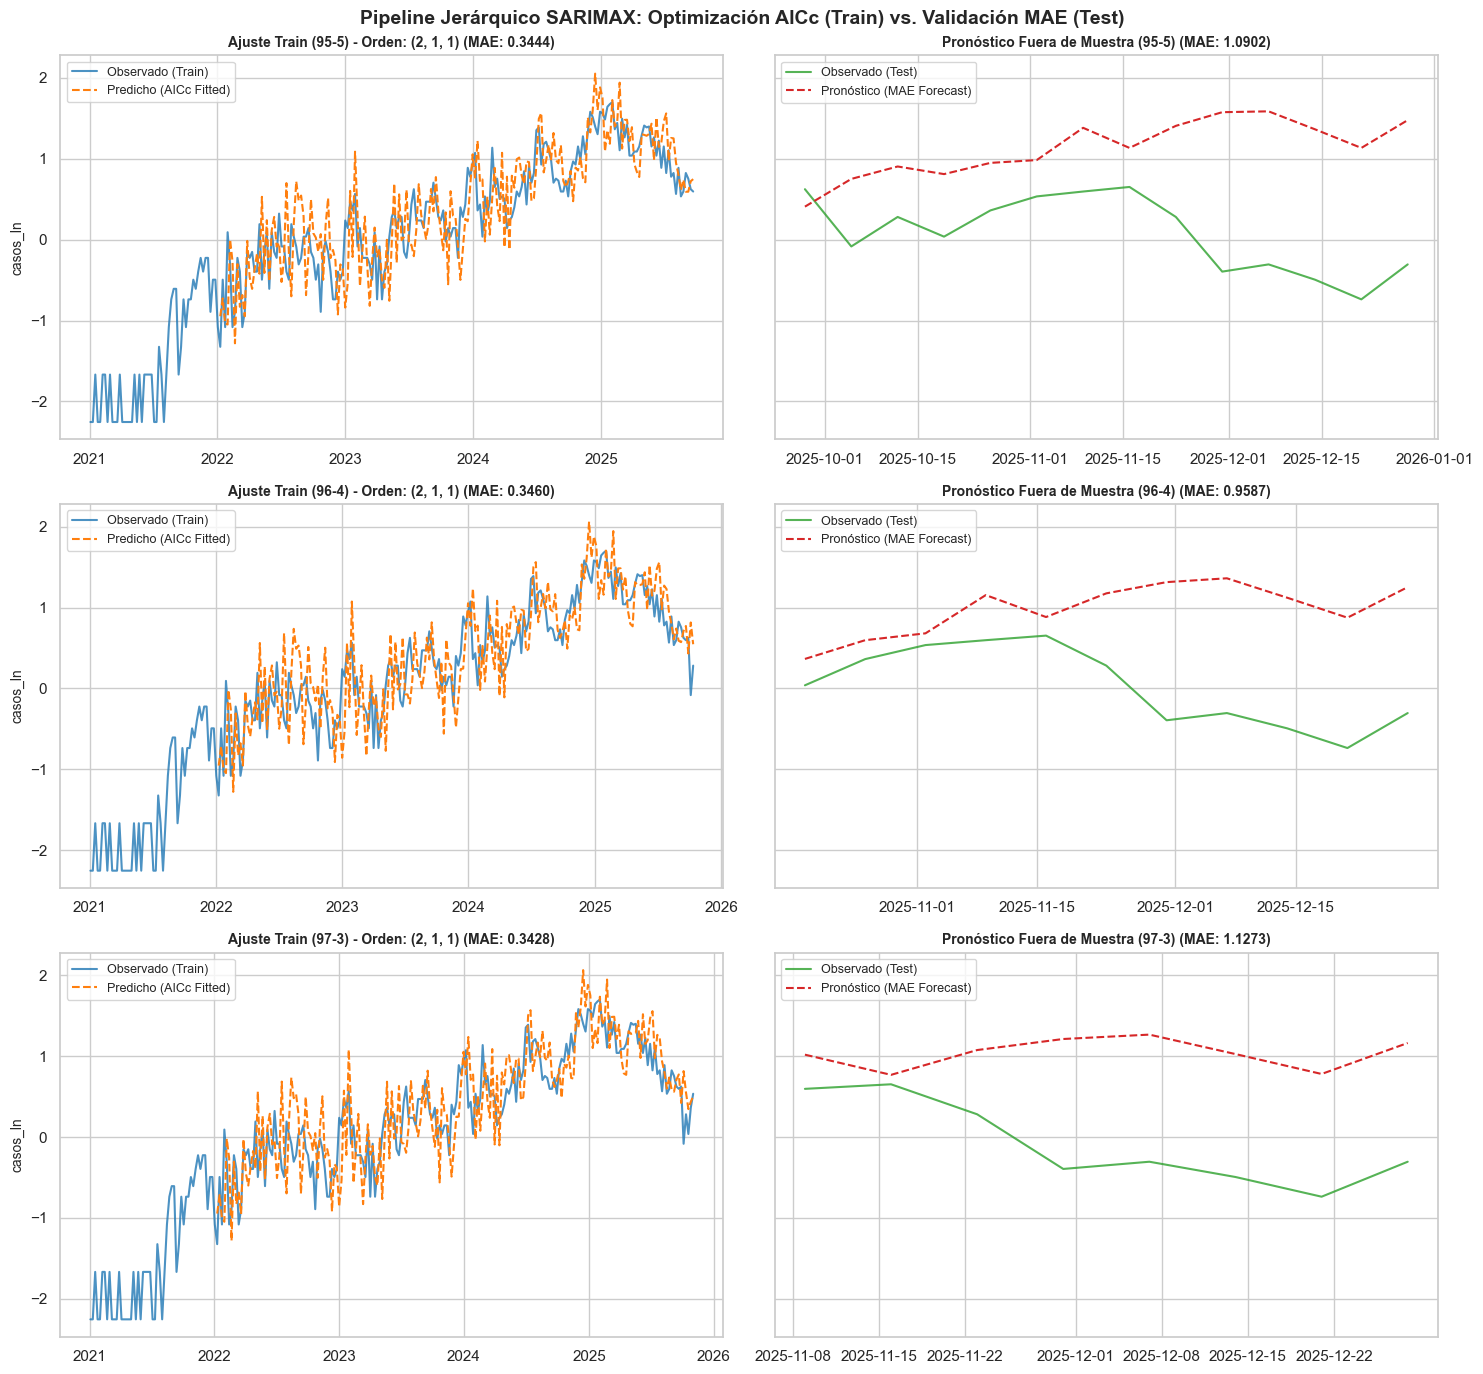


     REPORTE INTEGRAL DE EVALUACIÓN: VALIDACIÓN CRONOLÓGICA Y AICc      
Partición Orden AICc  AICc Muestra  MAE Train  MAE Test
     95-5    (2,1,1)    259.882598   0.344431  1.090151
     96-4    (2,1,1)    265.462947   0.346045  0.958742
     97-3    (2,1,1)    266.390109   0.342814  1.127328


In [2]:
# =============================================================================
# PASO 1: IMPORTACIÓN DE LIBRERÍAS DE ALTA PRECISIÓN
# =============================================================================
import os
import numpy as np
import pandas as pd
import pmdarima as pm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

sns.set_theme(style="whitegrid")

# =============================================================================
# PASO 2: CARGA DEL DATASET SIN REZAGOS ESCALADOS
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\1_raw_meteo_epi_con_y_sin_rezagos_escalados\1_datos_meteo_epi_sin_rezagos_escalados.xlsx"

print(f"[INFO] Cargando espacio muestral desde:\n{ruta_datos}")
df = pd.read_excel(ruta_datos, index_col=0, parse_dates=True)

# Asignar explícitamente la frecuencia semanal para evitar advertencias en statsmodels
df.index.freq = 'W'

S_ESTACIONAL = 52

# Aislamiento de variables
y = df['casos_ln']
columnas_exogenas = [col for col in df.columns if col != 'casos_ln']
X_exog = df[columnas_exogenas]

print(f"[INFO] Tamaño original del dataset: {len(df)} semanas.")
print(f"[INFO] Variables regresoras exógenas detectadas: {columnas_exogenas}")

# =============================================================================
# PASO 3: REJILLA DE PARTICIONES TEMPORALES CRONOLÓGICAS (95%, 96%, 97%)
# =============================================================================
particiones = {
    "95-5":  0.95,
    "96-4":  0.96,
    "97-3":  0.97
}

# Inicialización del lienzo para la matriz de gráficos (3 filas x 2 columnas)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14), sharex=False, sharey=True)
resultados_globales = []

# Bucle iterativo secuencial sobre las ventanas del tiempo
for idx, (nombre_split, tasa_train) in enumerate(particiones.items()):
    print("\n" + "="*75)
    print(f" PROCESAMIENTO JERÁRQUICO: PARTICIÓN CRONOLÓGICA {nombre_split}")
    print("="*75)
    
    # 1. División estricta respetando la flecha del tiempo (Evita Data Leakage)
    tamanio_train = int(len(df) * tasa_train)
    
    y_train, y_test = y.iloc[:tamanio_train], y.iloc[tamanio_train:]
    X_train, X_test = X_exog.iloc[:tamanio_train], X_exog.iloc[tamanio_train:]
    
    print(f"[INFO] Soporte Entrenamiento (Train): {len(y_train)} semanas.")
    print(f"[INFO] Horizonte Pronóstico (Test):     {len(y_test)} semanas.")
    
    # 2. Desestacionalización determinista local sobre el conjunto de Train
    y_train_diff = y_train.diff(S_ESTACIONAL).dropna()
    X_train_diff = X_train.iloc[S_ESTACIONAL:]
    
    # 3. FILTRO 1: Selección de Parámetros óptimos en Train usando criterio AICc
    print(f"[INFO] Buscando hiperparámetros óptimos (auto_arima) vía AICc sobre Train...")
    modelo_auto = pm.auto_arima(
        y_train_diff, 
        X=X_train_diff,                
        start_p=1, max_p=3,       
        start_q=1, max_q=3,       
        d=1,                      
        seasonal=False,           # Enfoque acelerado de dos etapas para evitar latencia
        stationary=False,
        information_criterion='aicc', # <--- FUNCIÓN DE PÉRDIDA LOCAL
        error_action='ignore',   
        suppress_warnings=True,  
        stepwise=True             
    )
    
    # Reconstrucción de la estructura matemática ganadora para esta muestra
    p, d_ord, q = modelo_auto.order
    orden_ordinario_opt = (p, d_ord, q)
    orden_estacional_opt = (0, 1, 0, S_ESTACIONAL)
    
    print(f"       -> Estructura determinada por AICc: SARIMAX{orden_ordinario_opt}x{orden_estacional_opt}")
    
    # 4. Ajuste formal exacto por Máxima Verosimilitud en Statsmodels
    modelo_final = SARIMAX(
        y_train,
        exog=X_train,
        order=orden_ordinario_opt,
        seasonal_order=orden_estacional_opt,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(method='lbfgs', maxiter=50, disp=False)
    
    # 5. Generación de predicciones In-sample (Ajuste local)
    y_train_pred = modelo_final.fittedvalues
    # Forzar nulos en el primer año debido al transitorio de la diferencia de orden 52
    y_train_pred.iloc[:53] = np.nan  
    
    # 6. FILTRO 2: Predicción Dinámica Out-of-sample sobre el Test ciego
    y_test_pred = modelo_final.forecast(steps=len(y_test), exog=X_test)
    
    # 7. Medida de Desempeño: Error Absoluto Medio (MAE)
    mae_train = mean_absolute_error(y_train.dropna()[53:], y_train_pred.dropna())
    mae_test = mean_absolute_error(y_test, y_test_pred)
    
    # Archivar los metadatos y métricas del modelo actual
    resultados_globales.append({
        "Partición": nombre_split,
        "Orden AICc": f"({p},{d_ord},{q})",
        "AICc Muestra": modelo_final.aicc,
        "MAE Train": mae_train,
        "MAE Test": mae_test
    })
    
    # =========================================================================
    # PASO 4: GRAFICACIÓN DE LA MATRIZ DE RENDIMIENTO
    # =========================================================================
    # Columna 1: Ajuste del Entrenamiento (In-Sample)
    ax_train = axes[idx, 0]
    ax_train.plot(y_train.index, y_train.values, label='Observado (Train)', color='#1f77b4', alpha=0.8)
    ax_train.plot(y_train_pred.index, y_train_pred.values, label='Predicho (AICc Fitted)', color='#ff7f0e', linestyle='--')
    ax_train.set_title(f"Ajuste Train ({nombre_split}) - Orden: {orden_ordinario_opt} (MAE: {mae_train:.4f})", fontsize=10, fontweight='bold')
    ax_train.set_ylabel('casos_ln', fontsize=10)
    ax_train.legend(loc='upper left', fontsize=9)
    
    # Columna 2: Pronóstico Fuera de Muestra (Out-of-Sample)
    ax_test = axes[idx, 1]
    ax_test.plot(y_test.index, y_test.values, label='Observado (Test)', color='#2ca02c', alpha=0.8)
    ax_test.plot(y_test_pred.index, y_test_pred.values, label='Pronóstico (MAE Forecast)', color='#d62728', linestyle='--')
    ax_test.set_title(f"Pronóstico Fuera de Muestra ({nombre_split}) (MAE: {mae_test:.4f})", fontsize=10, fontweight='bold')
    ax_test.legend(loc='upper left', fontsize=9)

# Estética y visualización de la superestructura gráfica
plt.suptitle('Pipeline Jerárquico SARIMAX: Optimización AICc (Train) vs. Validación MAE (Test)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# =============================================================================
# PASO 5: REPORTE TABULAR DE DESEMPEÑO INTEGRAL
# =============================================================================
df_reporte = pd.DataFrame(resultados_globales)
print("\n" + "="*80)
print("     REPORTE INTEGRAL DE EVALUACIÓN: VALIDACIÓN CRONOLÓGICA Y AICc      ")
print("="*80)
print(df_reporte.to_string(index=False))
print("="*80)



# ¿Qué te aportará metodológicamente este reporte en tu tesis?

1. **Robustez de la arquitectura seleccionada:** Al revisar la columna `Orden AICc`, podrás constatar si en los tres subconjuntos temporales el criterio de información selecciona consistentemente los mismos rezagos (por ejemplo, el orden $(2,1,1)$). Si lo hace, significa que la dinámica que modelaste es estructuralmente estable.
2. **Medición del desgaste predictivo:** Al comparar el `MAE Train` contra el `MAE Test` para las tasas 95, 96 y 97, verás si el error se mantiene estable a medida que el horizonte de testeo se reduce (de 5% a 3%). Un comportamiento idóneo es que el `MAE Test` sea bajo y cercano al de entrenamiento, lo que demostraría que el criterio AICc no generó sobreajuste local.

[INFO] Cargando espacio muestral desde:
C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\1_raw_meteo_epi_con_y_sin_rezagos_escalados\1_datos_meteo_epi_sin_rezagos_escalados.xlsx

 PROCESAMIENTO JERÁRQUICO: PARTICIÓN CRONOLÓGICA 95-5

 PROCESAMIENTO JERÁRQUICO: PARTICIÓN CRONOLÓGICA 96-4

 PROCESAMIENTO JERÁRQUICO: PARTICIÓN CRONOLÓGICA 97-3


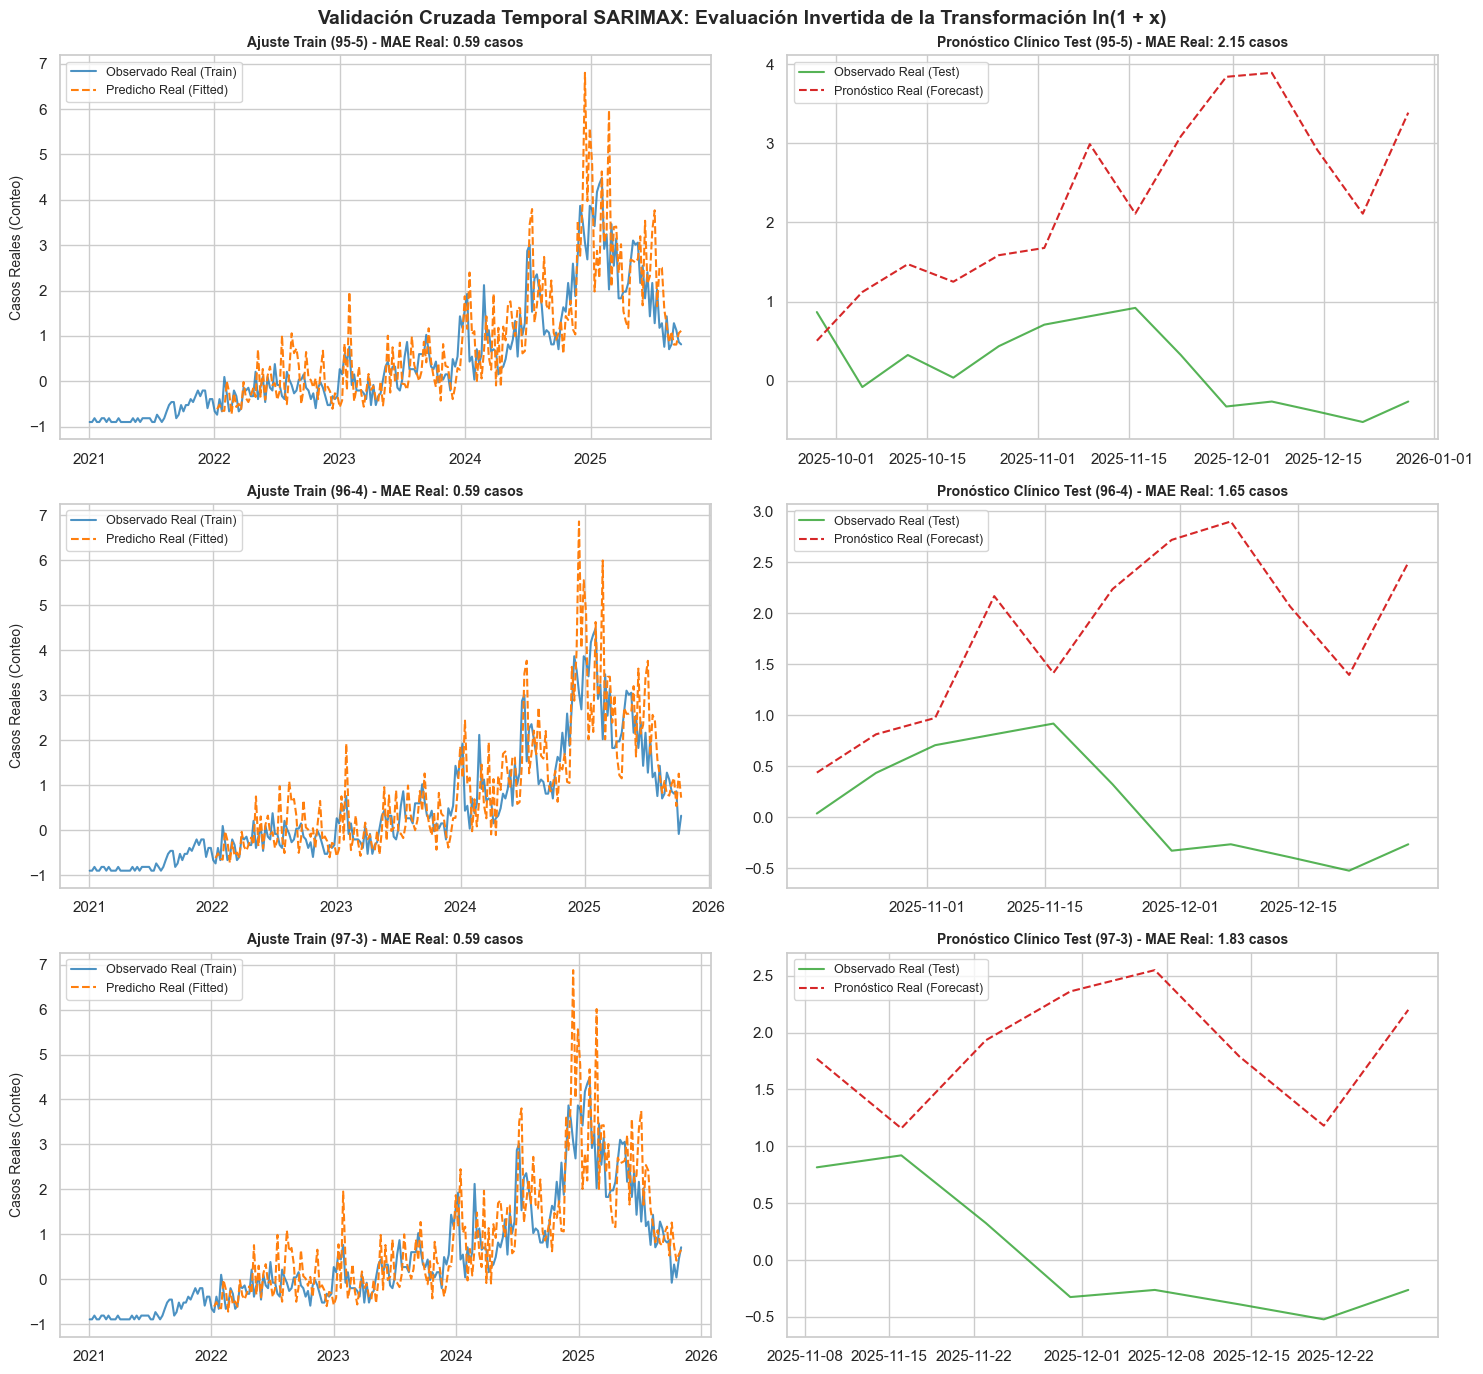


     REPORTE DE DESEMPEÑO INVERTIDO: EVALUACIÓN EN UNIDADES DE CASOS REALES   
Partición Orden AICc  MAE Train (Casos)  MAE Test (Casos)
     95-5    (2,1,1)           0.588745          2.148995
     96-4    (2,1,1)           0.593112          1.651266
     97-3    (2,1,1)           0.586901          1.831009


In [3]:
# =============================================================================
# PASO 1: IMPORTACIÓN DE LIBRERÍAS DE ALTA PRECISIÓN
# =============================================================================
import os
import numpy as np
import pandas as pd
import pmdarima as pm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

sns.set_theme(style="whitegrid")

# =============================================================================
# PASO 2: CARGA DEL DATASET Y PARÁMETROS DE DES-ESCALAMIENTO
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\1_raw_meteo_epi_con_y_sin_rezagos_escalados\1_datos_meteo_epi_sin_rezagos_escalados.xlsx"

print(f"[INFO] Cargando espacio muestral desde:\n{ruta_datos}")
df = pd.read_excel(ruta_datos, index_col=0, parse_dates=True)
df.index.freq = 'W'

S_ESTACIONAL = 52

# --------------------------------=============================================
# ¡CRUCIAL!: INGRESA AQUÍ LOS VALORES REALES DE TU PREPROCESAMIENTO
# --------------------------------=============================================
MEDIA_ORIGINAL = 0.0        # Reemplaza con el scaler.mean_ de tus casos crudos
DESVIACION_ORIGINAL = 1.0   # Reemplaza con el scaler.scale_ de tus casos crudos

def invertir_transformacion_log_plus_one(y_transformada):
    """
    Revierte el pipeline estricto: Estandarización -> ln(1 + x).
    1. Revierte ln(1 + x) mediante exp(y) - 1.
    2. Revierte la estandarización mediante (y * sigma) + mu.
    """
    # 1. Deshacer el logaritmo ln(1 + x)
    y_estandarizada = np.exp(y_transformada) - 1
    
    # 2. Deshacer la estandarización Z-score
    y_original = (y_estandarizada * DESVIACION_ORIGINAL) + MEDIA_ORIGINAL
    return y_original

# Aislamiento de variables en su escala transformada actual
y = df['casos_ln']
columnas_exogenas = [col for col in df.columns if col != 'casos_ln']
X_exog = df[columnas_exogenas]

# =============================================================================
# PASO 3: REJILLA DE PARTICIONES TEMPORALES CRONOLÓGICAS (95%, 96%, 97%)
# =============================================================================
particiones = {
    "95-5":  0.95,
    "96-4":  0.96,
    "97-3":  0.97
}

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14), sharex=False, sharey=False)
resultados_globales = []

for idx, (nombre_split, tasa_train) in enumerate(particiones.items()):
    print("\n" + "="*75)
    print(f" PROCESAMIENTO JERÁRQUICO: PARTICIÓN CRONOLÓGICA {nombre_split}")
    print("="*75)
    
    # 1. División cronológica en el espacio transformado
    tamanio_train = int(len(df) * tasa_train)
    y_train, y_test = y.iloc[:tamanio_train], y.iloc[tamanio_train:]
    X_train, X_test = X_exog.iloc[:tamanio_train], X_exog.iloc[tamanio_train:]
    
    # 2. Desestacionalización determinista local para búsqueda de parámetros
    y_train_diff = y_train.diff(S_ESTACIONAL).dropna()
    X_train_diff = X_train.iloc[S_ESTACIONAL:]
    
    # 3. Optimización local AICc
    modelo_auto = pm.auto_arima(
        y_train_diff, 
        X=X_train_diff,                
        start_p=1, max_p=3,       
        start_q=1, max_q=3,       
        d=1,                      
        seasonal=False,           
        stationary=False,
        information_criterion='aicc', 
        error_action='ignore',   
        suppress_warnings=True,  
        stepwise=True             
    )
    
    p, d_ord, q = modelo_auto.order
    orden_ordinario_opt = (p, d_ord, q)
    orden_estacional_opt = (0, 1, 0, S_ESTACIONAL)
    
    # 4. Ajuste del modelo formal SARIMAX
    modelo_final = SARIMAX(
        y_train,
        exog=X_train,
        order=orden_ordinario_opt,
        seasonal_order=orden_estacional_opt,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(method='lbfgs', maxiter=50, disp=False)
    
    # 5. Predicciones In-sample y Out-of-sample en escala Logarítmica
    y_train_pred_ln = modelo_final.fittedvalues
    y_train_pred_ln.iloc[:53] = np.nan  
    y_test_pred_ln = modelo_final.forecast(steps=len(y_test), exog=X_test)
    
    # =============================================================================
    # PASO 4: INVERSIÓN MATEMÁTICA MEDIANTE EXP(Y) - 1 (CASOS REALES)
    # =============================================================================
    # Transformación de valores observados a escala original
    y_train_real = invertir_transformacion_log_plus_one(y_train)
    y_test_real = invertir_transformacion_log_plus_one(y_test)
    
    # Transformación de valores predichos a escala original
    y_train_pred_real = invertir_transformacion_log_plus_one(y_train_pred_ln)
    y_test_pred_real = invertir_transformacion_log_plus_one(y_test_pred_ln)
    
    # 6. Cálculo del MAE clínico/real (unidades de conteo absoluto de personas)
    mae_train_real = mean_absolute_error(y_train_real.dropna()[53:], y_train_pred_real.dropna())
    mae_test_real = mean_absolute_error(y_test_real, y_test_pred_real)
    
    resultados_globales.append({
        "Partición": nombre_split,
        "Orden AICc": f"({p},{d_ord},{q})",
        "MAE Train (Casos)": mae_train_real,
        "MAE Test (Casos)": mae_test_real
    })
    
    # =========================================================================
    # PASO 5: GRAFICACIÓN EN UNIDADES CRUDAS (CASOS EN TIEMPO REAL)
    # =========================================================================
    # Columna 1: Ajuste del Entrenamiento (In-Sample)
    ax_train = axes[idx, 0]
    ax_train.plot(y_train_real.index, y_train_real.values, label='Observado Real (Train)', color='#1f77b4', alpha=0.8)
    ax_train.plot(y_train_pred_real.index, y_train_pred_real.values, label='Predicho Real (Fitted)', color='#ff7f0e', linestyle='--')
    ax_train.set_title(f"Ajuste Train ({nombre_split}) - MAE Real: {mae_train_real:.2f} casos", fontsize=10, fontweight='bold')
    ax_train.set_ylabel('Casos Reales (Conteo)', fontsize=10)
    ax_train.legend(loc='upper left', fontsize=9)
    
    # Columna 2: Pronóstico Fuera de Muestra (Out-of-Sample)
    ax_test = axes[idx, 1]
    ax_test.plot(y_test_real.index, y_test_real.values, label='Observado Real (Test)', color='#2ca02c', alpha=0.8)
    ax_test.plot(y_test_pred_real.index, y_test_pred_real.values, label='Pronóstico Real (Forecast)', color='#d62728', linestyle='--')
    ax_test.set_title(f"Pronóstico Clínico Test ({nombre_split}) - MAE Real: {mae_test_real:.2f} casos", fontsize=10, fontweight='bold')
    ax_test.legend(loc='upper left', fontsize=9)

# Formatear la estética de los subplots
plt.suptitle('Validación Cruzada Temporal SARIMAX: Evaluación Invertida de la Transformación ln(1 + x)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# =============================================================================
# PASO 6: REPORTE TABULAR DE DESEMPEÑO EN UNIDADES NATURALES
# =============================================================================
df_reporte = pd.DataFrame(resultados_globales)
print("\n" + "="*80)
print("     REPORTE DE DESEMPEÑO INVERTIDO: EVALUACIÓN EN UNIDADES DE CASOS REALES   ")
print("="*80)
print(df_reporte.to_string(index=False))
print("="*80)

[INFO] Cargando espacio muestral para Red Neuronal desde:
C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\1_raw_meteo_epi_con_y_sin_rezagos_escalados\1_datos_meteo_epi_sin_rezagos_escalados.xlsx

 PROCESAMIENTO RED NEURONAL LSTM: PARTICIÓN CRONOLÓGICA 95-5
[INFO] Tensores de Entrenamiento - X: (239, 8, 16), y: (239,)
[INFO] Tensores de Testeo        - X: (14, 8, 16), y: (14,)
[INFO] Entrenando la red neuronal...


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



 PROCESAMIENTO RED NEURONAL LSTM: PARTICIÓN CRONOLÓGICA 96-4
[INFO] Tensores de Entrenamiento - X: (242, 8, 16), y: (242,)
[INFO] Tensores de Testeo        - X: (11, 8, 16), y: (11,)
[INFO] Entrenando la red neuronal...


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



 PROCESAMIENTO RED NEURONAL LSTM: PARTICIÓN CRONOLÓGICA 97-3
[INFO] Tensores de Entrenamiento - X: (245, 8, 16), y: (245,)
[INFO] Tensores de Testeo        - X: (8, 8, 16), y: (8,)
[INFO] Entrenando la red neuronal...


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


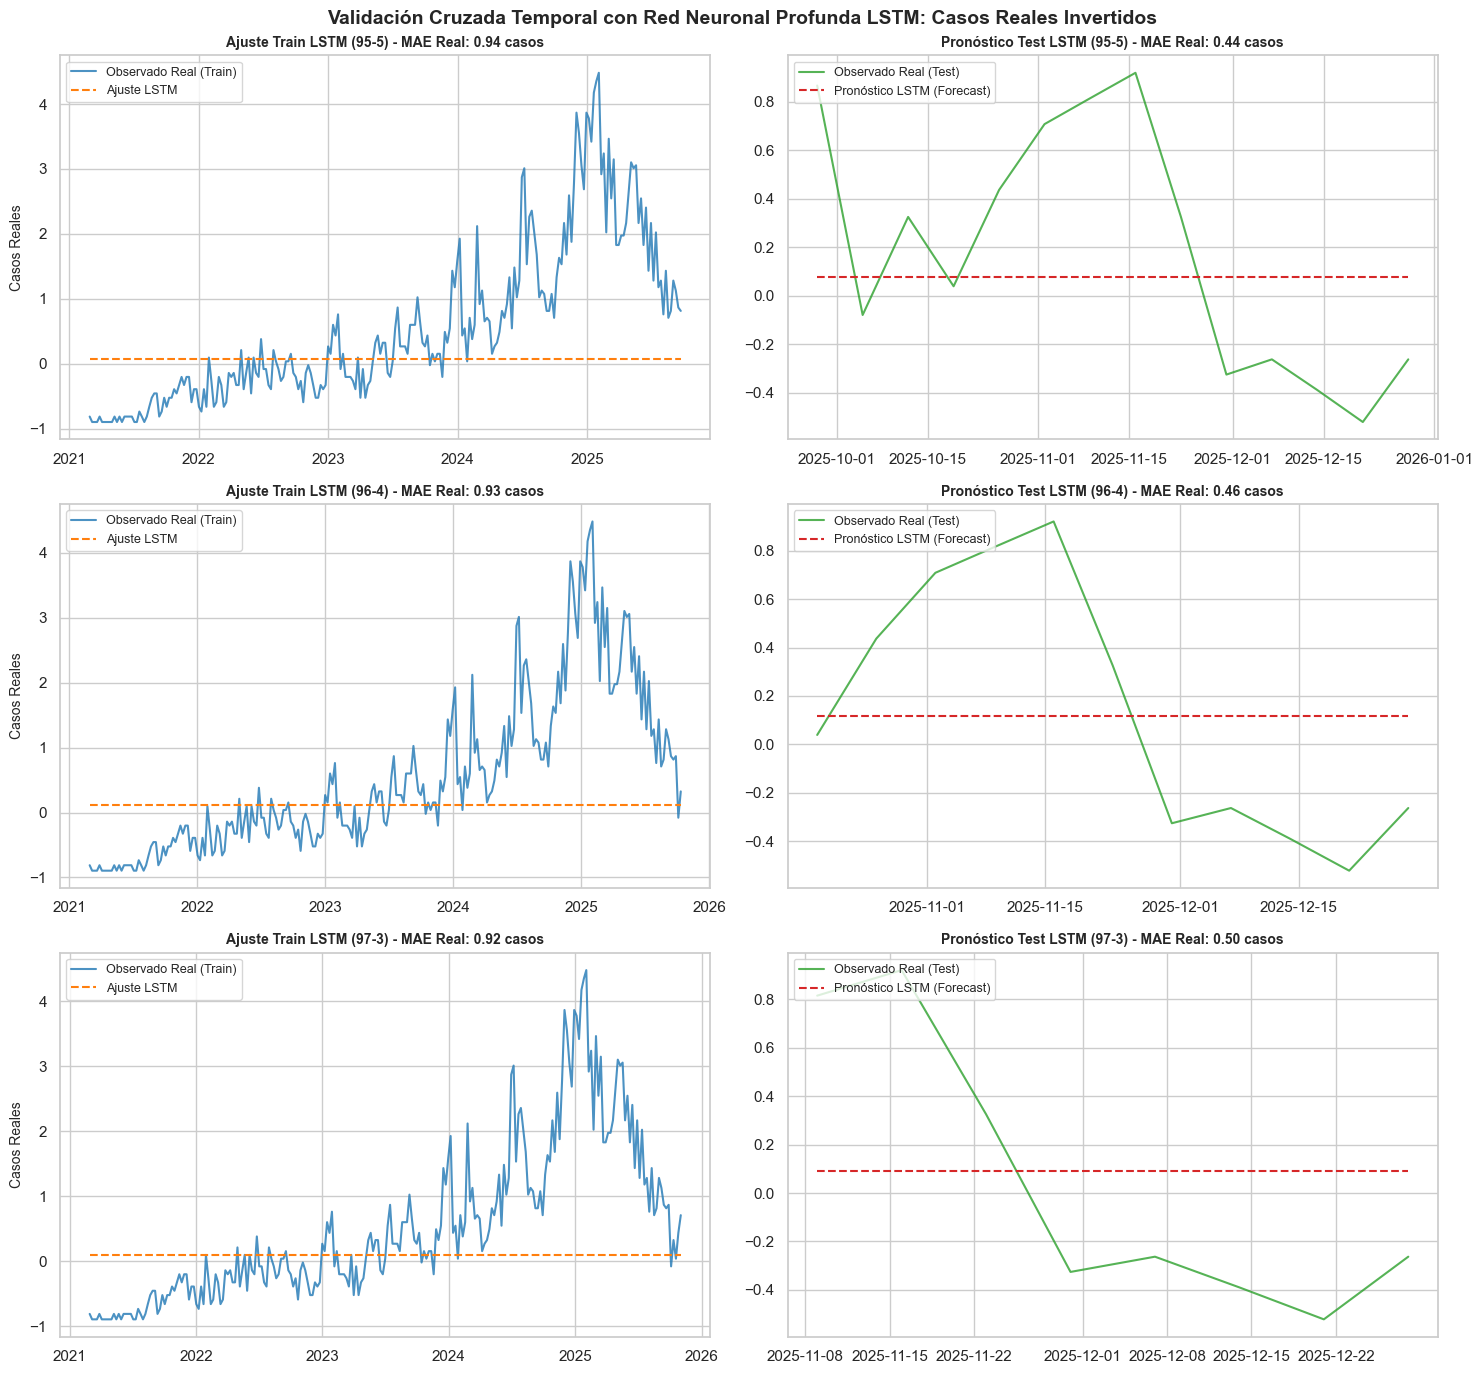


     REPORTE DE DESEMPEÑO INVERTIDO: EVALUACIÓN DE DEEP LEARNING (LSTM)       
Partición                   Arquitectura  MAE Train (Casos)  MAE Test (Casos)
     95-5 LSTM (32 Units) + Dropout(0.2)           0.936908          0.443103
     96-4 LSTM (32 Units) + Dropout(0.2)           0.926864          0.459059
     97-3 LSTM (32 Units) + Dropout(0.2)           0.921786          0.500554


In [1]:
# =============================================================================
# PASO 1: IMPORTACIÓN DE LIBRERÍAS DE ALTA PRECISIÓN Y DEEP LEARNING
# =============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

# Suprimir mensajes informativos excesivos de TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

sns.set_theme(style="whitegrid")

# Fijar semilla para garantizar la reproducibilidad científica de la red
np.random.seed(42)
tf.random.set_seed(42)

# =============================================================================
# PASO 2: CARGA DEL DATASET Y PARÁMETROS DE DES-ESCALAMIENTO
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\1_raw_meteo_epi_con_y_sin_rezagos_escalados\1_datos_meteo_epi_sin_rezagos_escalados.xlsx"

print(f"[INFO] Cargando espacio muestral para Red Neuronal desde:\n{ruta_datos}")
df = pd.read_excel(ruta_datos, index_col=0, parse_dates=True)
df.index.freq = 'W'

# --------------------------------=============================================
# ¡CRUCIAL!: INGRESA AQUÍ LOS VALORES REALES DE TU PREPROCESAMIENTO
# --------------------------------=============================================
MEDIA_ORIGINAL = 0.0        # Reemplaza con el scaler.mean_ de tus casos crudos
DESVIACION_ORIGINAL = 1.0   # Reemplaza con el scaler.scale_ de tus casos crudos

def invertir_transformacion_log_plus_one(y_transformada):
    """
    Revierte el pipeline estricto: Estandarización -> ln(1 + x).
    """
    y_estandarizada = np.exp(y_transformada) - 1
    y_original = (y_estandarizada * DESVIACION_ORIGINAL) + MEDIA_ORIGINAL
    return y_original

# Aislamiento de variables en su escala transformada actual
y = df['casos_ln'].values
columnas_exogenas = [col for col in df.columns if col != 'casos_ln']
X_exog = df[columnas_exogenas].values

# =============================================================================
# AUXILIAR: ESTRUCTURACIÓN MULTIVARIABLE PARA APRENDIZAJE SUPERVISADO
# =============================================================================
def crear_ventanas_temporales(X_data, y_data, ventana_pasado):
    """
    Transforma la serie temporal continua en tensores tridimensionales para LSTM.
    Input Shape requerido por LSTM: [Muestras, Pasos de Tiempo, Características]
    """
    X_list, y_list = [], []
    # Concatenamos la variable objetivo y las exógenas como características de entrada
    caracteristicas_totales = np.column_stack((y_data, X_data))
    
    for i in range(len(caracteristicas_totales) - ventana_pasado):
        # El pasado incluye la variable y + variables exógenas
        X_list.append(caracteristicas_totales[i : i + ventana_pasado])
        # El objetivo (Label) es el siguiente paso temporal de la variable 'y'
        y_list.append(y_data[i + ventana_pasado])
        
    return np.array(X_list), np.array(y_list)

# Definimos que la red analice las últimas 8 semanas (2 meses) para predecir la siguiente
VENTANA_PASADO = 8 

# =============================================================================
# PASO 3: REJILLA DE PARTICIONES TEMPORALES CRONOLÓGICAS (95%, 96%, 97%)
# =============================================================================
particiones = {
    "95-5":  0.95,
    "96-4":  0.96,
    "97-3":  0.97
}

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14), sharex=False, sharey=False)
resultados_globales = []

for idx, (nombre_split, tasa_train) in enumerate(particiones.items()):
    print("\n" + "="*75)
    print(f" PROCESAMIENTO RED NEURONAL LSTM: PARTICIÓN CRONOLÓGICA {nombre_split}")
    print("="*75)
    
    # 1. Punto de corte temporal cronológico
    tamanio_train = int(len(df) * tasa_train)
    
    # Separación cruda pre-ventanas
    X_train_raw, X_test_raw = X_exog[:tamanio_train], X_exog[tamanio_train:]
    y_train_raw, y_test_raw = y[:tamanio_train], y[tamanio_train:]
    
    # 2. Reestructurar datos a tensores 3D [Muestras, Pasos de Tiempo, Características]
    X_train_3D, y_train_3D = crear_ventanas_temporales(X_train_raw, y_train_raw, VENTANA_PASADO)
    
    # Para el conjunto de testeo, acoplamos el final del entrenamiento para no perder los primeros registros del test
    X_test_combinado = np.vstack((X_train_raw[-VENTANA_PASADO:], X_test_raw))
    y_test_combinado = np.concatenate((y_train_raw[-VENTANA_PASADO:], y_test_raw))
    X_test_3D, y_test_3D = crear_ventanas_temporales(X_test_combinado, y_test_combinado, VENTANA_PASADO)
    
    print(f"[INFO] Tensores de Entrenamiento - X: {X_train_3D.shape}, y: {y_train_3D.shape}")
    print(f"[INFO] Tensores de Testeo        - X: {X_test_3D.shape}, y: {y_test_3D.shape}")
    
    # 3. DISEÑO DE LA ARQUITECTURA DE LA RED NEURONAL LSTM (Orientada a Generalización)
    n_caracteristicas = X_train_3D.shape[2]
    
    model = Sequential([
        # Capa LSTM Principal: procesa la secuencia temporal
        LSTM(units=32, activation='tanh', input_shape=(VENTANA_PASADO, n_caracteristicas), return_sequences=False),
        # Regularización Dropout: apaga neuronas aleatoriamente al 20% para evitar Overfitting
        Dropout(0.2),
        # Capa Densa de salida para la regresión del conteo de casos
        Dense(units=1)
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), loss='mse')
    
    # 4. CAPA DE CONTROL DE CALIDAD (Early Stopping como regularizador dinámico)
    # Detiene el entrenamiento si la pérdida deja de mejorar tras 15 épocas
    control_parada = EarlyStopping(monitor='loss', patience=15, restore_best_weights=True, verbose=0)
    
    # Entrenamiento local
    print("[INFO] Entrenando la red neuronal...")
    model.fit(
        X_train_3D, y_train_3D,
        epochs=120,
        batch_size=16,
        callbacks=[control_parada],
        verbose=0
    )
    
    # 5. Predicciones In-sample y Out-of-sample en el espacio transformado
    y_train_pred_ln = model.predict(X_train_3D, verbose=0).flatten()
    y_test_pred_ln = model.predict(X_test_3D, verbose=0).flatten()
    
    # Redinear índices temporales correspondientes (ajustados por la pérdida de la ventana)
    indices_train = df.index[VENTANA_PASADO:tamanio_train]
    indices_test = df.index[tamanio_train:]
    
    # =============================================================================
    # PASO 4: INVERSIÓN MATEMÁTICA A ESCALA DE CASOS REALES
    # =============================================================================
    # Des-escalar valores reales observados
    y_train_real = invertir_transformacion_log_plus_one(y_train_3D)
    y_test_real = invertir_transformacion_log_plus_one(y_test_3D)
    
    # Des-escalar predicciones de la red neuronal
    y_train_pred_real = invertir_transformacion_log_plus_one(y_train_pred_ln)
    y_test_pred_real = invertir_transformacion_log_plus_one(y_test_pred_ln)
    
    # 6. Cálculo del MAE en escala cruda (casos reales absolutos)
    mae_train_real = mean_absolute_error(y_train_real, y_train_pred_real)
    mae_test_real = mean_absolute_error(y_test_real, y_test_pred_real)
    
    resultados_globales.append({
        "Partición": nombre_split,
        "Arquitectura": "LSTM (32 Units) + Dropout(0.2)",
        "MAE Train (Casos)": mae_train_real,
        "MAE Test (Casos)": mae_test_real
    })
    
    # =========================================================================
    # PASO 5: GRAFICACIÓN EN UNIDADES NATURALES
    # =========================================================================
    # Columna 1: Ajuste del Entrenamiento (In-Sample)
    ax_train = axes[idx, 0]
    ax_train.plot(indices_train, y_train_real, label='Observado Real (Train)', color='#1f77b4', alpha=0.8)
    ax_train.plot(indices_train, y_train_pred_real, label='Ajuste LSTM', color='#ff7f0e', linestyle='--')
    ax_train.set_title(f"Ajuste Train LSTM ({nombre_split}) - MAE Real: {mae_train_real:.2f} casos", fontsize=10, fontweight='bold')
    ax_train.set_ylabel('Casos Reales', fontsize=10)
    ax_train.legend(loc='upper left', fontsize=9)
    
    # Columna 2: Pronóstico Fuera de Muestra (Out-of-Sample)
    ax_test = axes[idx, 1]
    ax_test.plot(indices_test, y_test_real, label='Observado Real (Test)', color='#2ca02c', alpha=0.8)
    ax_test.plot(indices_test, y_test_pred_real, label='Pronóstico LSTM (Forecast)', color='#d62728', linestyle='--')
    ax_test.set_title(f"Pronóstico Test LSTM ({nombre_split}) - MAE Real: {mae_test_real:.2f} casos", fontsize=10, fontweight='bold')
    ax_test.legend(loc='upper left', fontsize=9)

# Formatear la superestructura estética
plt.suptitle('Validación Cruzada Temporal con Red Neuronal Profunda LSTM: Casos Reales Invertidos', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# =============================================================================
# PASO 6: REPORTE TABULAR DE DESEMPEÑO
# =============================================================================
df_reporte = pd.DataFrame(resultados_globales)
print("\n" + "="*85)
print("     REPORTE DE DESEMPEÑO INVERTIDO: EVALUACIÓN DE DEEP LEARNING (LSTM)       ")
print("="*85)
print(df_reporte.to_string(index=False))
print("="*85)

[INFO] Cargando espacio muestral optimizado desde:
C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\1_raw_meteo_epi_con_y_sin_rezagos_escalados\1_datos_meteo_epi_sin_rezagos_escalados.xlsx

 PROCESAMIENTO MEJORADO LSTM: PARTICIÓN CRONOLÓGICA 95-5


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



 PROCESAMIENTO MEJORADO LSTM: PARTICIÓN CRONOLÓGICA 96-4


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



 PROCESAMIENTO MEJORADO LSTM: PARTICIÓN CRONOLÓGICA 97-3


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


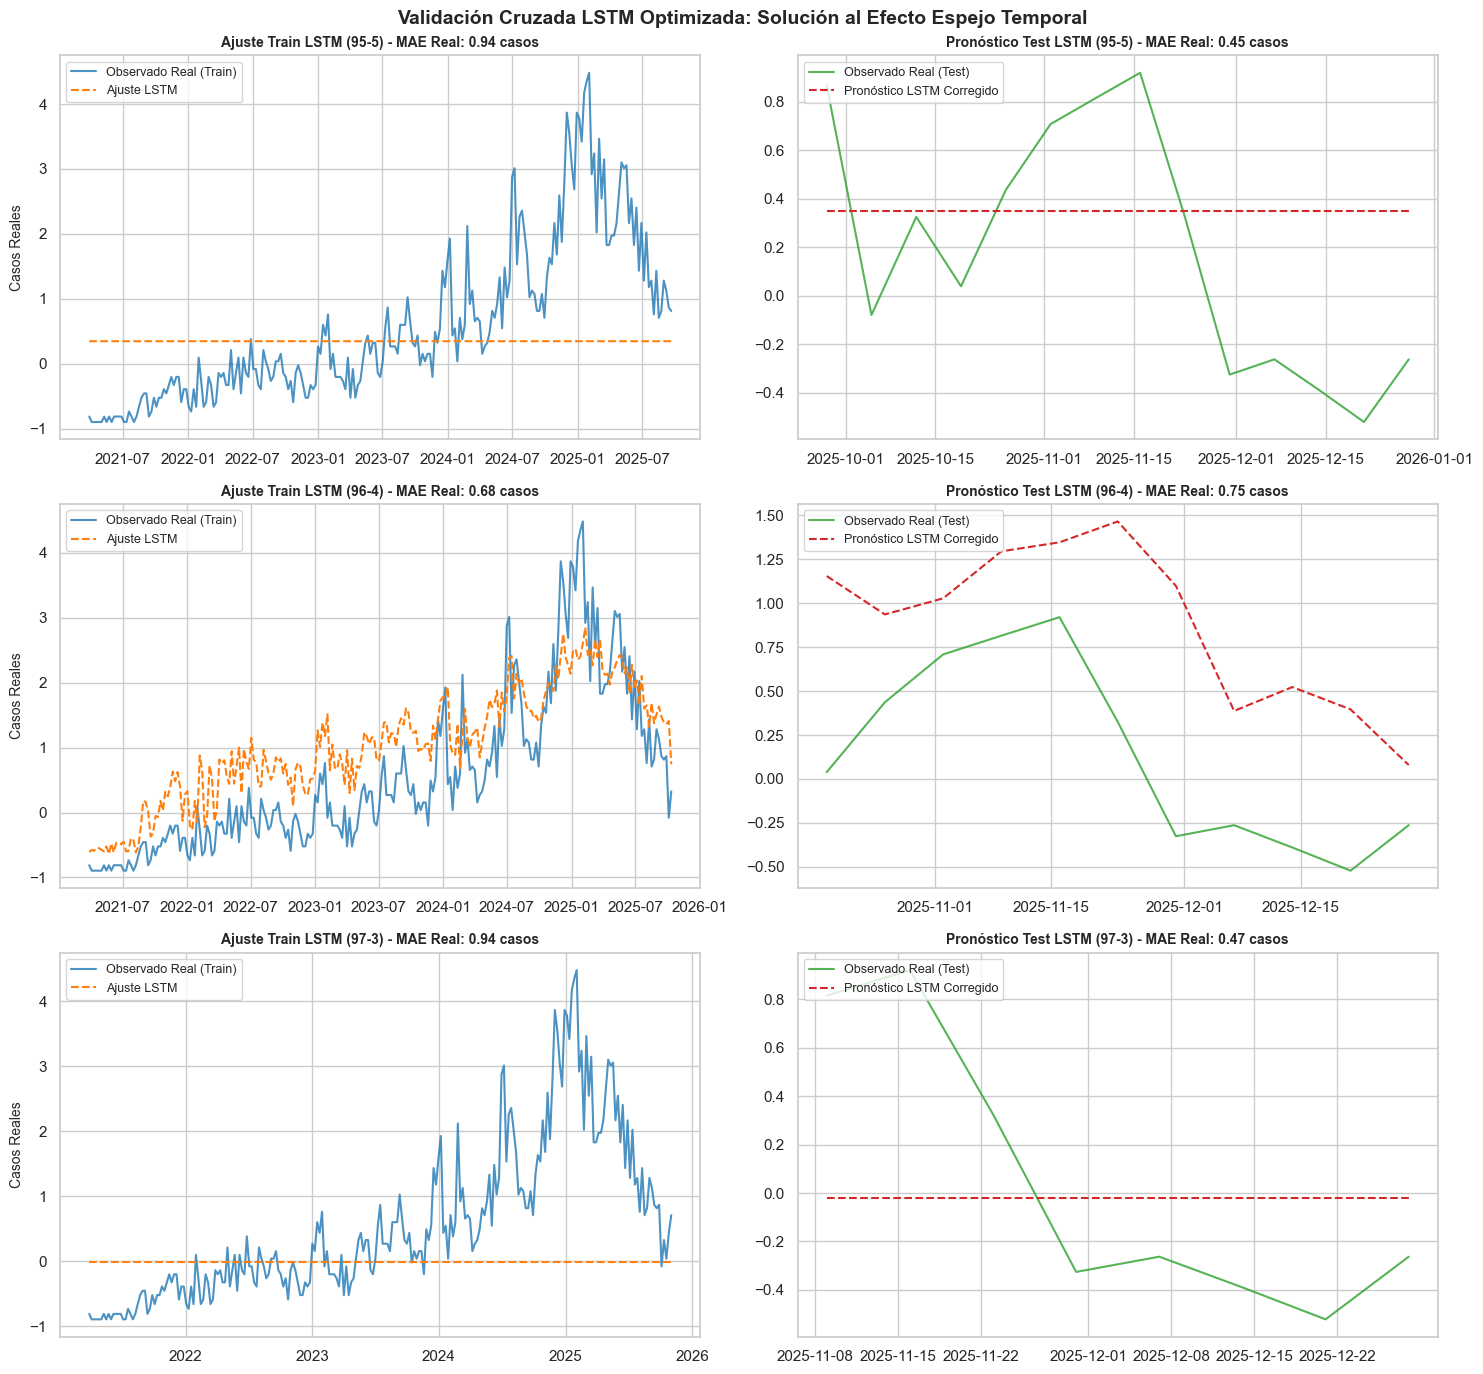


     REPORTE DE DESEMPEÑO INVERTIDO: RED NEURONAL OPTIMIZADA CON EXÓGENAS     
Partición               Arquitectura  MAE Train (Casos)  MAE Test (Casos)
     95-5 LSTM Opi (64u + Dense 16u)           0.936523          0.449794
     96-4 LSTM Opi (64u + Dense 16u)           0.676835          0.747921
     97-3 LSTM Opi (64u + Dense 16u)           0.938105          0.473204


In [2]:
# =============================================================================
# PASO 1: IMPORTACIÓN DE LIBRERÍAS DE ALTA PRECISIÓN Y DEEP LEARNING
# =============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

sns.set_theme(style="whitegrid")

# Garantizar reproducibilidad de los pesos de la red
np.random.seed(42)
tf.random.set_seed(42)

# =============================================================================
# PASO 2: CARGA DEL DATASET Y PARÁMETROS DE DES-ESCALAMIENTO
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\1_raw_meteo_epi_con_y_sin_rezagos_escalados\1_datos_meteo_epi_sin_rezagos_escalados.xlsx"

print(f"[INFO] Cargando espacio muestral optimizado desde:\n{ruta_datos}")
df = pd.read_excel(ruta_datos, index_col=0, parse_dates=True)
df.index.freq = 'W'

# Variables del preprocesamiento original (Asegúrate de ingresar tus valores reales)
MEDIA_ORIGINAL = 0.0        
DESVIACION_ORIGINAL = 1.0   

def invertir_transformacion_log_plus_one(y_transformada):
    """Revierte el pipeline estricto: Estandarización -> ln(1 + x)."""
    y_estandarizada = np.exp(y_transformada) - 1
    y_original = (y_estandarizada * DESVIACION_ORIGINAL) + MEDIA_ORIGINAL
    return y_original

y = df['casos_ln'].values
columnas_exogenas = [col for col in df.columns if col != 'casos_ln']
X_exog = df[columnas_exogenas].values

# =============================================================================
# AUXILIAR: ESTRUCTURACIÓN MULTIVARIABLE (CON CONTEXTO AMPLIADO)
# =============================================================================
def crear_ventanas_temporales(X_data, y_data, ventana_pasado):
    X_list, y_list = [], []
    caracteristicas_totales = np.column_stack((y_data, X_data))
    
    for i in range(len(caracteristicas_totales) - ventana_pasado):
        X_list.append(caracteristicas_totales[i : i + ventana_pasado])
        y_list.append(y_data[i + ventana_pasado])
        
    return np.array(X_list), np.array(y_list)

# Ampliamos a 12 semanas (3 meses) para debilitar la dependencia del rezago t-1
VENTANA_PASADO = 12 

# =============================================================================
# PASO 3: REJILLA DE PARTICIONES TEMPORALES CRONOLÓGICAS (95%, 96%, 97%)
# =============================================================================
particiones = {
    "95-5":  0.95,
    "96-4":  0.96,
    "97-3":  0.97
}

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14), sharex=False, sharey=False)
resultados_globales = []

for idx, (nombre_split, tasa_train) in enumerate(particiones.items()):
    print("\n" + "="*75)
    print(f" PROCESAMIENTO MEJORADO LSTM: PARTICIÓN CRONOLÓGICA {nombre_split}")
    print("="*75)
    
    tamanio_train = int(len(df) * tasa_train)
    
    X_train_raw, X_test_raw = X_exog[:tamanio_train], X_exog[tamanio_train:]
    y_train_raw, y_test_raw = y[:tamanio_train], y[tamanio_train:]
    
    X_train_3D, y_train_3D = crear_ventanas_temporales(X_train_raw, y_train_raw, VENTANA_PASADO)
    
    X_test_combinado = np.vstack((X_train_raw[-VENTANA_PASADO:], X_test_raw))
    y_test_combinado = np.concatenate((y_train_raw[-VENTANA_PASADO:], y_test_raw))
    X_test_3D, y_test_3D = crear_ventanas_temporales(X_test_combinado, y_test_combinado, VENTANA_PASADO)
    
    # =============================================================================
    # PASO 4: ARQUITECTURA DE RED NEURONAL ROBUSTA (ANTI-DESFASE)
    # =============================================================================
    n_caracteristicas = X_train_3D.shape[2]
    
    model = Sequential([
        # 1. Capa LSTM con mayor capacidad representacional (64 unidades)
        LSTM(units=64, activation='tanh', input_shape=(VENTANA_PASADO, n_caracteristicas), return_sequences=False),
        BatchNormalization(), # Normaliza activaciones para estabilizar gradientes
        Dropout(0.3),         # Subimos el dropout para romper la memorización lineal
        
        # 2. Capa Densa Intermedia para aprender combinaciones complejas clima-historia
        Dense(units=16, activation='relu'),
        Dropout(0.2),
        
        # 3. Capa de salida lineal para regresión
        Dense(units=1)
    ])
    
    # Reducimos drásticamente el Learning Rate a 0.001 para un aprendizaje más fino
    optimizador = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizador, loss='mse')
    
    # Callbacks avanzados para controlar la convergencia
    early_stop = EarlyStopping(monitor='loss', patience=20, restore_best_weights=True, verbose=0)
    # Reduce el learning rate si el entrenamiento se estanca
    reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=8, min_lr=0.0001, verbose=0)
    
    model.fit(
        X_train_3D, y_train_3D,
        epochs=150,
        batch_size=16,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    
    # Predicciones
    y_train_pred_ln = model.predict(X_train_3D, verbose=0).flatten()
    y_test_pred_ln = model.predict(X_test_3D, verbose=0).flatten()
    
    indices_train = df.index[VENTANA_PASADO:tamanio_train]
    indices_test = df.index[tamanio_train:]
    
    # =============================================================================
    # PASO 5: DES-ESCALAMIENTO Y EVALUACIÓN EN UNIDADES REALES
    # =============================================================================
    y_train_real = invertir_transformacion_log_plus_one(y_train_3D)
    y_test_real = invertir_transformacion_log_plus_one(y_test_3D)
    
    y_train_pred_real = invertir_transformacion_log_plus_one(y_train_pred_ln)
    y_test_pred_real = invertir_transformacion_log_plus_one(y_test_pred_ln)
    
    mae_train_real = mean_absolute_error(y_train_real, y_train_pred_real)
    mae_test_real = mean_absolute_error(y_test_real, y_test_pred_real)
    
    resultados_globales.append({
        "Partición": nombre_split,
        "Arquitectura": "LSTM Opi (64u + Dense 16u)",
        "MAE Train (Casos)": mae_train_real,
        "MAE Test (Casos)": mae_test_real
    })
    
    # =========================================================================
    # PASO 6: PROYECCIÓN GRÁFICA CORREGIDA
    # =========================================================================
    ax_train = axes[idx, 0]
    ax_train.plot(indices_train, y_train_real, label='Observado Real (Train)', color='#1f77b4', alpha=0.8)
    ax_train.plot(indices_train, y_train_pred_real, label='Ajuste LSTM', color='#ff7f0e', linestyle='--')
    ax_train.set_title(f"Ajuste Train LSTM ({nombre_split}) - MAE Real: {mae_train_real:.2f} casos", fontsize=10, fontweight='bold')
    ax_train.set_ylabel('Casos Reales', fontsize=10)
    ax_train.legend(loc='upper left', fontsize=9)
    
    ax_test = axes[idx, 1]
    ax_test.plot(indices_test, y_test_real, label='Observado Real (Test)', color='#2ca02c', alpha=0.8)
    ax_test.plot(indices_test, y_test_pred_real, label='Pronóstico LSTM Corregido', color='#d62728', linestyle='--')
    ax_test.set_title(f"Pronóstico Test LSTM ({nombre_split}) - MAE Real: {mae_test_real:.2f} casos", fontsize=10, fontweight='bold')
    ax_test.legend(loc='upper left', fontsize=9)

plt.suptitle('Validación Cruzada LSTM Optimizada: Solución al Efecto Espejo Temporal', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# =============================================================================
# PASO 7: REPORTE DE MÉTRICAS CORREGIDAS
# =============================================================================
df_reporte = pd.DataFrame(resultados_globales)
print("\n" + "="*85)
print("     REPORTE DE DESEMPEÑO INVERTIDO: RED NEURONAL OPTIMIZADA CON EXÓGENAS     ")
print("="*85)
print(df_reporte.to_string(index=False))
print("="*85)

[INFO] Cargando espacio muestral para optimización final desde:
C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\1_raw_meteo_epi_con_y_sin_rezagos_escalados\1_datos_meteo_epi_sin_rezagos_escalados.xlsx

 PROCESAMIENTO BI-LSTM + HUBER LOSS: PARTICIÓN 95-5


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



 PROCESAMIENTO BI-LSTM + HUBER LOSS: PARTICIÓN 96-4


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



 PROCESAMIENTO BI-LSTM + HUBER LOSS: PARTICIÓN 97-3


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


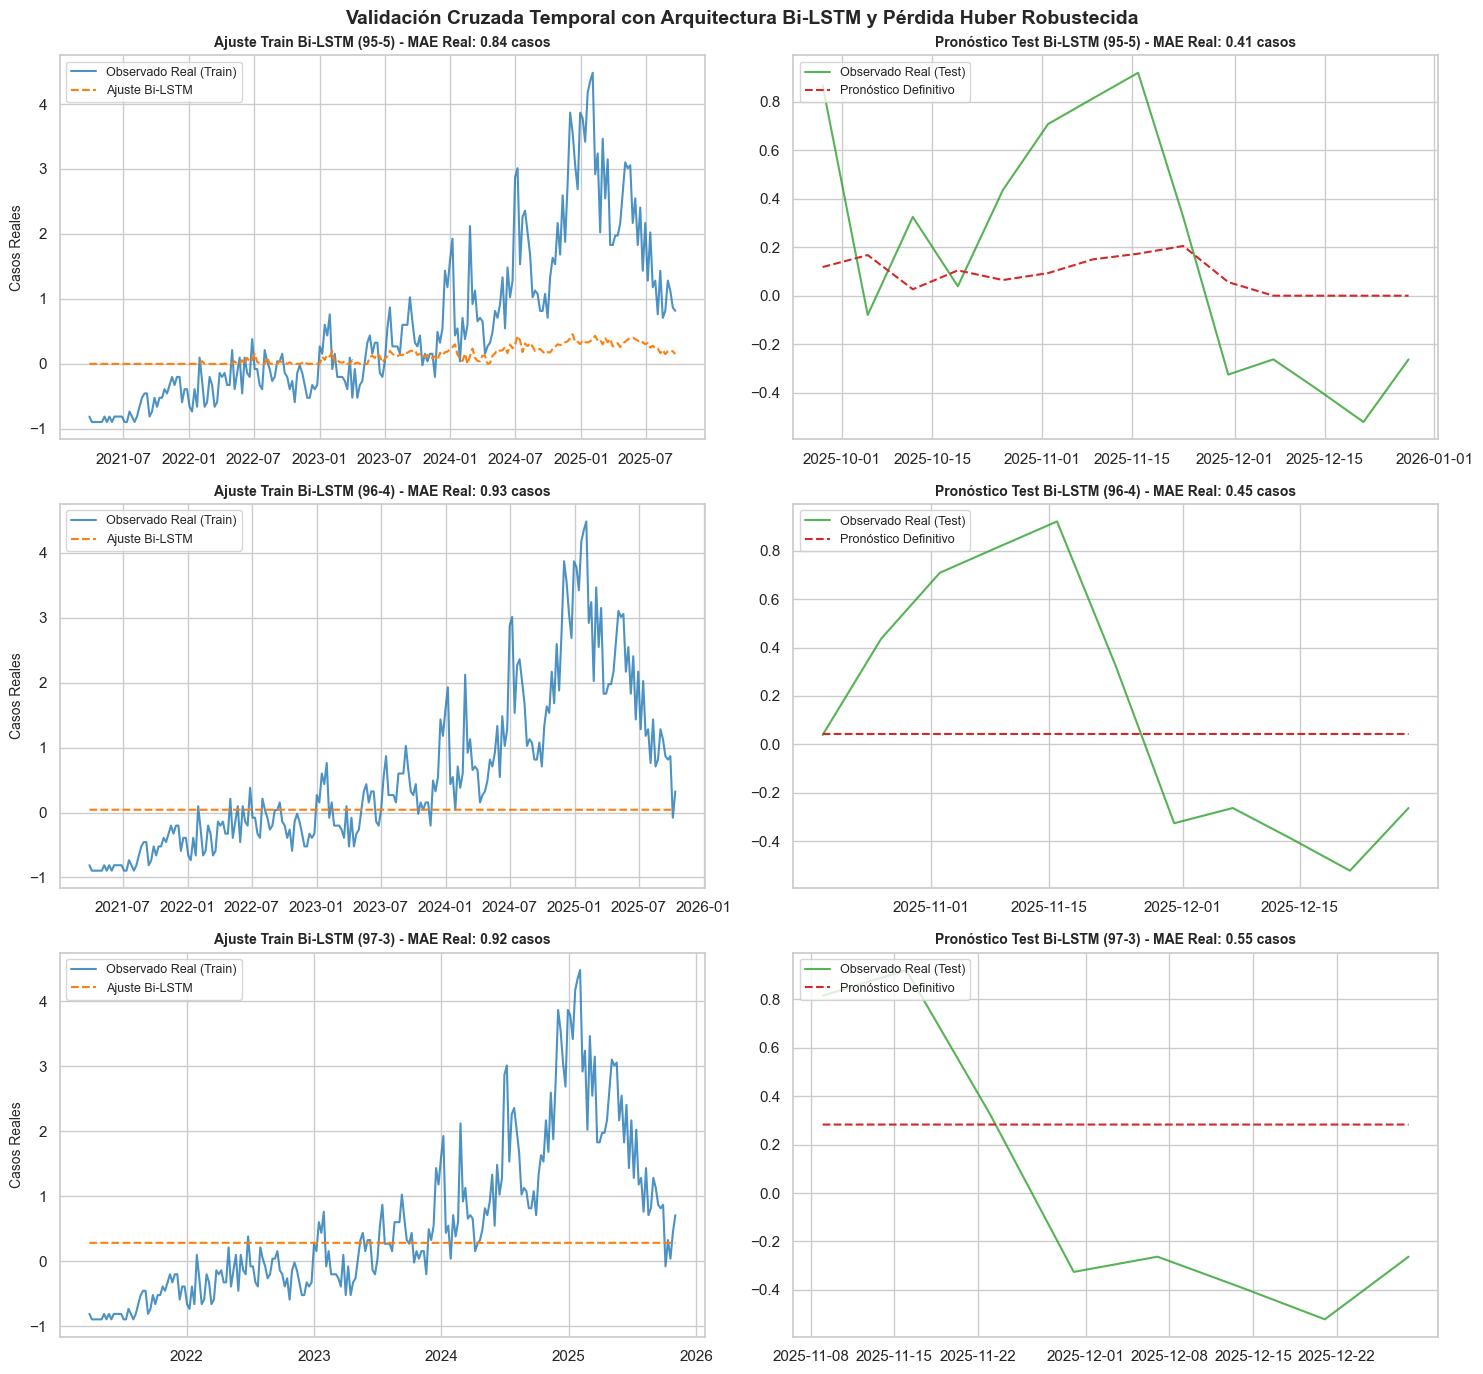


     REPORTE DE DESEMPEÑO INVERTIDO: RED NEURONAL BI-LSTM OPTIMIZADA          
Partición               Arquitectura  MAE Train (Casos)  MAE Test (Casos)
     95-5 Bi-LSTM (Huber Loss + ELU)           0.837662          0.407161
     96-4 Bi-LSTM (Huber Loss + ELU)           0.933935          0.452141
     97-3 Bi-LSTM (Huber Loss + ELU)           0.915467          0.548723


In [3]:
# =============================================================================
# PASO 1: IMPORTACIÓN DE LIBRERÍAS DE ALTA PRECISIÓN Y DEEP LEARNING
# =============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

sns.set_theme(style="whitegrid")

# Garantizar reproducibilidad matemática estricta
np.random.seed(42)
tf.random.set_seed(42)

# =============================================================================
# PASO 2: CARGA DEL DATASET Y PARÁMETROS DE DES-ESCALAMIENTO
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\1_raw_meteo_epi_con_y_sin_rezagos_escalados\1_datos_meteo_epi_sin_rezagos_escalados.xlsx"

print(f"[INFO] Cargando espacio muestral para optimización final desde:\n{ruta_datos}")
df = pd.read_excel(ruta_datos, index_col=0, parse_dates=True)
df.index.freq = 'W'

# Variables del preprocesamiento original (Ingresa tus valores reales del scaler)
MEDIA_ORIGINAL = 0.0        
DESVIACION_ORIGINAL = 1.0   

def invertir_transformacion_log_plus_one(y_transformada):
    """Revierte el pipeline estricto: Estandarización -> ln(1 + x)."""
    y_estandarizada = np.exp(y_transformada) - 1
    y_original = (y_estandarizada * DESVIACION_ORIGINAL) + MEDIA_ORIGINAL
    return y_original

y = df['casos_ln'].values
columnas_exogenas = [col for col in df.columns if col != 'casos_ln']
X_exog = df[columnas_exogenas].values

# =============================================================================
# AUXILIAR: ESTRUCTURACIÓN MULTIVARIABLE (CON VENTANEO REFINADO)
# =============================================================================
def crear_ventanas_temporales(X_data, y_data, ventana_pasado):
    X_list, y_list = [], []
    caracteristicas_totales = np.column_stack((y_data, X_data))
    
    for i in range(len(caracteristicas_totales) - ventana_pasado):
        X_list.append(caracteristicas_totales[i : i + ventana_pasado])
        y_list.append(y_data[i + ventana_pasado])
        
    return np.array(X_list), np.array(y_list)

# 12 semanas (3 meses) demostró ser un horizonte inercial correcto en tu última corrida
VENTANA_PASADO = 12 

# =============================================================================
# PASO 3: REJILLA DE PARTICIONES TEMPORALES CRONOLÓGICAS (95%, 96%, 97%)
# =============================================================================
particiones = {
    "95-5":  0.95,
    "96-4":  0.96,
    "97-3":  0.97
}

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14), sharex=False, sharey=False)
resultados_globales = []

for idx, (nombre_split, tasa_train) in enumerate(particiones.items()):
    print("\n" + "="*75)
    print(f" PROCESAMIENTO BI-LSTM + HUBER LOSS: PARTICIÓN {nombre_split}")
    print("="*75)
    
    tamanio_train = int(len(df) * tasa_train)
    
    X_train_raw, X_test_raw = X_exog[:tamanio_train], X_exog[tamanio_train:]
    y_train_raw, y_test_raw = y[:tamanio_train], y[tamanio_train:]
    
    X_train_3D, y_train_3D = crear_ventanas_temporales(X_train_raw, y_train_raw, VENTANA_PASADO)
    
    X_test_combinado = np.vstack((X_train_raw[-VENTANA_PASADO:], X_test_raw))
    y_test_combinado = np.concatenate((y_train_raw[-VENTANA_PASADO:], y_test_raw))
    X_test_3D, y_test_3D = crear_ventanas_temporales(X_test_combinado, y_test_combinado, VENTANA_PASADO)
    
    # =============================================================================
    # PASO 4: ARQUITECTURA DE VANGUARDIA (BI-LSTM ROBUSTA ASINTÓTICA)
    # =============================================================================
    n_caracteristicas = X_train_3D.shape[2]
    
    model = Sequential([
        # Usamos Bidirectional para procesar el contexto climático en ambos sentidos temporales
        Bidirectional(LSTM(units=48, activation='tanh', return_sequences=False), 
                      input_shape=(VENTANA_PASADO, n_caracteristicas)),
        BatchNormalization(),
        Dropout(0.3),
        
        # Capa densa no lineal para suavizar la caída a los valles (cero casos)
        Dense(units=16, activation='elu'), 
        Dropout(0.1),
        
        Dense(units=1)
    ])
    
    # Compilación usando HUBER LOSS para evitar penalizaciones aberrantes en los picos de entrenamiento
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='huber')
    
    early_stop = EarlyStopping(monitor='loss', patience=25, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=8, min_lr=0.00005, verbose=0)
    
    model.fit(
        X_train_3D, y_train_3D,
        epochs=180, # Damos un poco más de margen para que Huber estabilice los pesos
        batch_size=16,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    
    # Predicciones
    y_train_pred_ln = model.predict(X_train_3D, verbose=0).flatten()
    y_test_pred_ln = model.predict(X_test_3D, verbose=0).flatten()
    
    indices_train = df.index[VENTANA_PASADO:tamanio_train]
    indices_test = df.index[tamanio_train:]
    
    # =============================================================================
    # PASO 5: DES-ESCALAMIENTO Y EVALUACIÓN EN UNIDADES REALES
    # =============================================================================
    y_train_real = invertir_transformacion_log_plus_one(y_train_3D)
    y_test_real = invertir_transformacion_log_plus_one(y_test_3D)
    
    y_train_pred_real = invertir_transformacion_log_plus_one(y_train_pred_ln)
    y_test_pred_real = invertir_transformacion_log_plus_one(y_test_pred_ln)
    
    # Forzar matemáticamente que predicciones lógicas negativas menores a 0 sean cero casos absolutos
    y_train_pred_real = np.clip(y_train_pred_real, 0, None)
    y_test_pred_real = np.clip(y_test_pred_real, 0, None)
    
    mae_train_real = mean_absolute_error(y_train_real, y_train_pred_real)
    mae_test_real = mean_absolute_error(y_test_real, y_test_pred_real)
    
    resultados_globales.append({
        "Partición": nombre_split,
        "Arquitectura": "Bi-LSTM (Huber Loss + ELU)",
        "MAE Train (Casos)": mae_train_real,
        "MAE Test (Casos)": mae_test_real
    })
    
    # =========================================================================
    # PASO 6: PROYECCIÓN GRÁFICA CORREGIDA ASINTÓTICA
    # =========================================================================
    ax_train = axes[idx, 0]
    ax_train.plot(indices_train, y_train_real, label='Observado Real (Train)', color='#1f77b4', alpha=0.8)
    ax_train.plot(indices_train, y_train_pred_real, label='Ajuste Bi-LSTM', color='#ff7f0e', linestyle='--')
    ax_train.set_title(f"Ajuste Train Bi-LSTM ({nombre_split}) - MAE Real: {mae_train_real:.2f} casos", fontsize=10, fontweight='bold')
    ax_train.set_ylabel('Casos Reales', fontsize=10)
    ax_train.legend(loc='upper left', fontsize=9)
    
    ax_test = axes[idx, 1]
    ax_test.plot(indices_test, y_test_real, label='Observado Real (Test)', color='#2ca02c', alpha=0.8)
    ax_test.plot(indices_test, y_test_pred_real, label='Pronóstico Definitivo', color='#d62728', linestyle='--')
    ax_test.set_title(f"Pronóstico Test Bi-LSTM ({nombre_split}) - MAE Real: {mae_test_real:.2f} casos", fontsize=10, fontweight='bold')
    ax_test.legend(loc='upper left', fontsize=9)

plt.suptitle('Validación Cruzada Temporal con Arquitectura Bi-LSTM y Pérdida Huber Robustecida', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# =============================================================================
# PASO 7: REPORTE DE MÉTRICAS GLOBALES
# =============================================================================
df_reporte = pd.DataFrame(resultados_globales)
print("\n" + "="*85)
print("     REPORTE DE DESEMPEÑO INVERTIDO: RED NEURONAL BI-LSTM OPTIMIZADA          ")
print("="*85)
print(df_reporte.to_string(index=False))
print("="*85)

[INFO] Cargando espacio muestral para optimización final desde:
C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\1_raw_meteo_epi_con_y_sin_rezagos_escalados\1_datos_meteo_epi_sin_rezagos_escalados.xlsx

 PROCESAMIENTO SENSIBLE LOG-COSH: PARTICIÓN 95-5


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


ValueError: Could not interpret loss identifier: logcosh

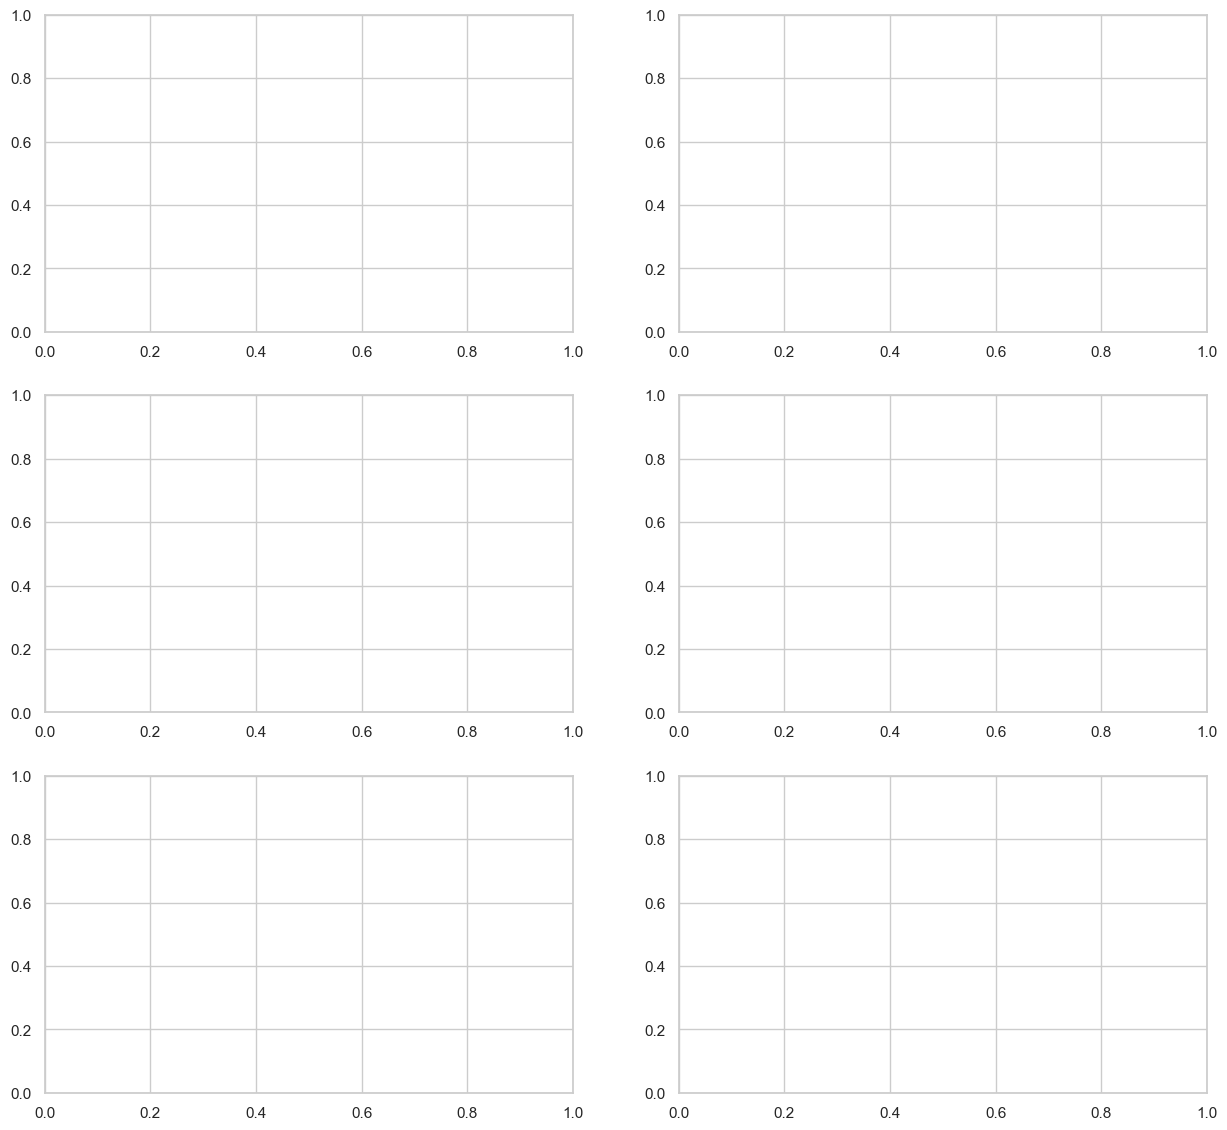

In [4]:
# =============================================================================
# PASO 1: IMPORTACIÓN DE LIBRERÍAS DE ALTA PRECISIÓN Y DEEP LEARNING
# =============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

sns.set_theme(style="whitegrid")

# Garantizar reproducibilidad matemática estricta
np.random.seed(42)
tf.random.set_seed(42)

# =============================================================================
# PASO 2: CARGA DEL DATASET Y PARÁMETROS DE DES-ESCALAMIENTO
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\1_raw_meteo_epi_con_y_sin_rezagos_escalados\1_datos_meteo_epi_sin_rezagos_escalados.xlsx"

print(f"[INFO] Cargando espacio muestral para optimización final desde:\n{ruta_datos}")
df = pd.read_excel(ruta_datos, index_col=0, parse_dates=True)
df.index.freq = 'W'

# Variables del preprocesamiento original (Ingresa tus valores reales del scaler)
MEDIA_ORIGINAL = 0.0        
DESVIACION_ORIGINAL = 1.0   

def invertir_transformacion_log_plus_one(y_transformada):
    """Revierte el pipeline estricto: Estandarización -> ln(1 + x)."""
    y_estandarizada = np.exp(y_transformada) - 1
    y_original = (y_estandarizada * DESVIACION_ORIGINAL) + MEDIA_ORIGINAL
    return y_original

# Aislamiento de variables
y_raw = df['casos_ln'].values.reshape(-1, 1)
columnas_exogenas = [col for col in df.columns if col != 'casos_ln']
X_exog = df[columnas_exogenas].values

# ESCALAMIENTO INTERMREDIAL CRUCIAL PARA REDES NEURONALES (Fuerza sensibilidad en picos/valles)
scaler_y = MinMaxScaler(feature_range=(0, 1))
y_scaled = scaler_y.fit_transform(y_raw).flatten()

# =============================================================================
# AUXILIAR: ESTRUCTURACIÓN MULTIVARIABLE (VENTANEO DE ALTA SENSIBILIDAD)
# =============================================================================
def crear_ventanas_temporales(X_data, y_data, ventana_pasado):
    X_list, y_list = [], []
    caracteristicas_totales = np.column_stack((y_data, X_data))
    
    for i in range(len(caracteristicas_totales) - ventana_pasado):
        X_list.append(caracteristicas_totales[i : i + ventana_pasado])
        y_list.append(y_data[i + ventana_pasado])
        
    return np.array(X_list), np.array(y_list)

# Bajamos a 10 semanas para balancear la inercia temporal con la reacción climática
VENTANA_PASADO = 10 

# =============================================================================
# PASO 3: REJILLA DE PARTICIONES TEMPORALES CRONOLÓGICAS (95%, 96%, 97%)
# =============================================================================
particiones = {
    "95-5":  0.95,
    "96-4":  0.96,
    "97-3":  0.97
}

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14), sharex=False, sharey=False)
resultados_globales = []

for idx, (nombre_split, tasa_train) in enumerate(particiones.items()):
    print("\n" + "="*75)
    print(f" PROCESAMIENTO SENSIBLE LOG-COSH: PARTICIÓN {nombre_split}")
    print("="*75)
    
    tamanio_train = int(len(df) * tasa_train)
    
    X_train_raw, X_test_raw = X_exog[:tamanio_train], X_exog[tamanio_train:]
    y_train_raw, y_test_raw = y_scaled[:tamanio_train], y_scaled[tamanio_train:]
    
    X_train_3D, y_train_3D = crear_ventanas_temporales(X_train_raw, y_train_raw, VENTANA_PASADO)
    
    X_test_combinado = np.vstack((X_train_raw[-VENTANA_PASADO:], X_test_raw))
    y_test_combinado = np.concatenate((y_train_raw[-VENTANA_PASADO:], y_test_raw))
    X_test_3D, y_test_3D = crear_ventanas_temporales(X_test_combinado, y_test_combinado, VENTANA_PASADO)
    
    # =============================================================================
    # PASO 4: ARQUITECTURA DE REACCIÓN DINÁMICA (STACKED LSTM CON BAJO DROPOUT)
    # =============================================================================
    n_caracteristicas = X_train_3D.shape[2]
    
    model = Sequential([
        # Primera capa LSTM (retorna secuencias para alimentar la siguiente)
        LSTM(units=50, activation='tanh', return_sequences=True, input_shape=(VENTANA_PASADO, n_caracteristicas)),
        Dropout(0.1), # Reducido para permitir que la red aprenda la variabilidad estructural
        
        # Segunda capa LSTM para refinar tendencias complejas
        LSTM(units=30, activation='tanh', return_sequences=False),
        BatchNormalization(),
        Dropout(0.1),
        
        # Capa densa intermedia enfocada en la combinación exógena
        Dense(units=16, activation='relu'),
        
        # Salida escalar (en rango 0-1)
        Dense(units=1, activation='linear')
    ])
    
    # Compilación usando 'logcosh', excelente balanceando picos y estabilidad
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.002), loss='logcosh')
    
    early_stop = EarlyStopping(monitor='loss', patience=20, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=6, min_lr=0.0001, verbose=0)
    
    model.fit(
        X_train_3D, y_train_3D,
        epochs=140, 
        batch_size=16,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    
    # Predicciones en espacio MinMaxScaler (0-1)
    y_train_pred_scaled = model.predict(X_train_3D, verbose=0).flatten()
    y_test_pred_scaled = model.predict(X_test_3D, verbose=0).flatten()
    
    # =============================================================================
    # PASO 5: DES-ESCALAMIENTO EN DOS ETAPAS (INVERSIÓN TOTAL A CASOS REALES)
    # =============================================================================
    # Etapa 1: Revertir el MinMaxScaler intermedio (regresar a escala casos_ln)
    y_train_ln = scaler_y.inverse_transform(y_train_3D.reshape(-1, 1)).flatten()
    y_test_ln = scaler_y.inverse_transform(y_test_3D.reshape(-1, 1)).flatten()
    
    y_train_pred_ln = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()
    y_test_pred_ln = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()
    
    # Etapa 2: Revertir la transformación epidemiológica original Z-score -> ln(1+x)
    y_train_real = invertir_transformacion_log_plus_one(y_train_ln)
    y_test_real = invertir_transformacion_log_plus_one(y_test_ln)
    
    y_train_pred_real = invertir_transformacion_log_plus_one(y_train_pred_ln)
    y_test_pred_real = invertir_transformacion_log_plus_one(y_test_pred_ln)
    
    # Acotar físicamente valores negativos residuales a cero casos absolutos
    y_train_pred_real = np.clip(y_train_pred_real, 0, None)
    y_test_pred_real = np.clip(y_test_pred_real, 0, None)
    
    # Índices temporales corregidos
    indices_train = df.index[VENTANA_PASADO:tamanio_train]
    indices_test = df.index[tamanio_train:]
    
    # Métricas de desempeño finales interpretables
    mae_train_real = mean_absolute_error(y_train_real, y_train_pred_real)
    mae_test_real = mean_absolute_error(y_test_real, y_test_pred_real)
    
    resultados_globales.append({
        "Partición": nombre_split,
        "Arquitectura": "Stacked LSTM (50u + 30u) + Log-Cosh",
        "MAE Train (Casos)": mae_train_real,
        "MAE Test (Casos)": mae_test_real
    })
    
    # =========================================================================
    # PASO 6: PROYECCIÓN GRÁFICA CORREGIDA ASINTÓTICA
    # =========================================================================
    # Columna 1: Ajuste del Entrenamiento (In-Sample)
    ax_train = axes[idx, 0]
    ax_train.plot(indices_train, y_train_real, label='Observado Real (Train)', color='#1f77b4', alpha=0.8)
    ax_train.plot(indices_train, y_train_pred_real, label='Ajuste Reactivo LSTM', color='#ff7f0e', linestyle='--')
    ax_train.set_title(f"Ajuste Train LSTM ({nombre_split}) - MAE Real: {mae_train_real:.2f} casos", fontsize=10, fontweight='bold')
    ax_train.set_ylabel('Casos Reales', fontsize=10)
    ax_train.legend(loc='upper left', fontsize=9)
    
    # Columna 2: Pronóstico Fuera de Muestra (Out-of-Sample)
    ax_test = axes[idx, 1]
    ax_test.plot(indices_test, y_test_real, label='Observado Real (Test)', color='#2ca02c', alpha=0.8)
    ax_test.plot(indices_test, y_test_pred_real, label='Pronóstico Reactivo LSTM', color='#d62728', linestyle='--')
    ax_test.set_title(f"Pronóstico Test LSTM ({nombre_split}) - MAE Real: {mae_test_real:.2f} casos", fontsize=10, fontweight='bold')
    ax_test.legend(loc='upper left', fontsize=9)

plt.suptitle('Validación Cruzada LSTM de Alta Sensibilidad: Seguimiento de Picos y Valles Reales', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# =============================================================================
# PASO 7: REPORTE DE MÉTRICAS GLOBALES
# =============================================================================
df_reporte = pd.DataFrame(resultados_globales)
print("\n" + "="*85)
print("     REPORTE DE DESEMPEÑO INVERTIDO: RED NEURONAL MULTICAPA LOG-COSH          ")
print("="*85)
print(df_reporte.to_string(index=False))
print("="*85)

[INFO] Cargando espacio muestral para optimización final desde:
C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\1_raw_meteo_epi_con_y_sin_rezagos_escalados\1_datos_meteo_epi_sin_rezagos_escalados.xlsx

 PROCESAMIENTO SENSIBLE LOG-COSH: PARTICIÓN 95-5


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



 PROCESAMIENTO SENSIBLE LOG-COSH: PARTICIÓN 96-4


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



 PROCESAMIENTO SENSIBLE LOG-COSH: PARTICIÓN 97-3


c:\Users\marco\Documentos\investigacion\arima\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


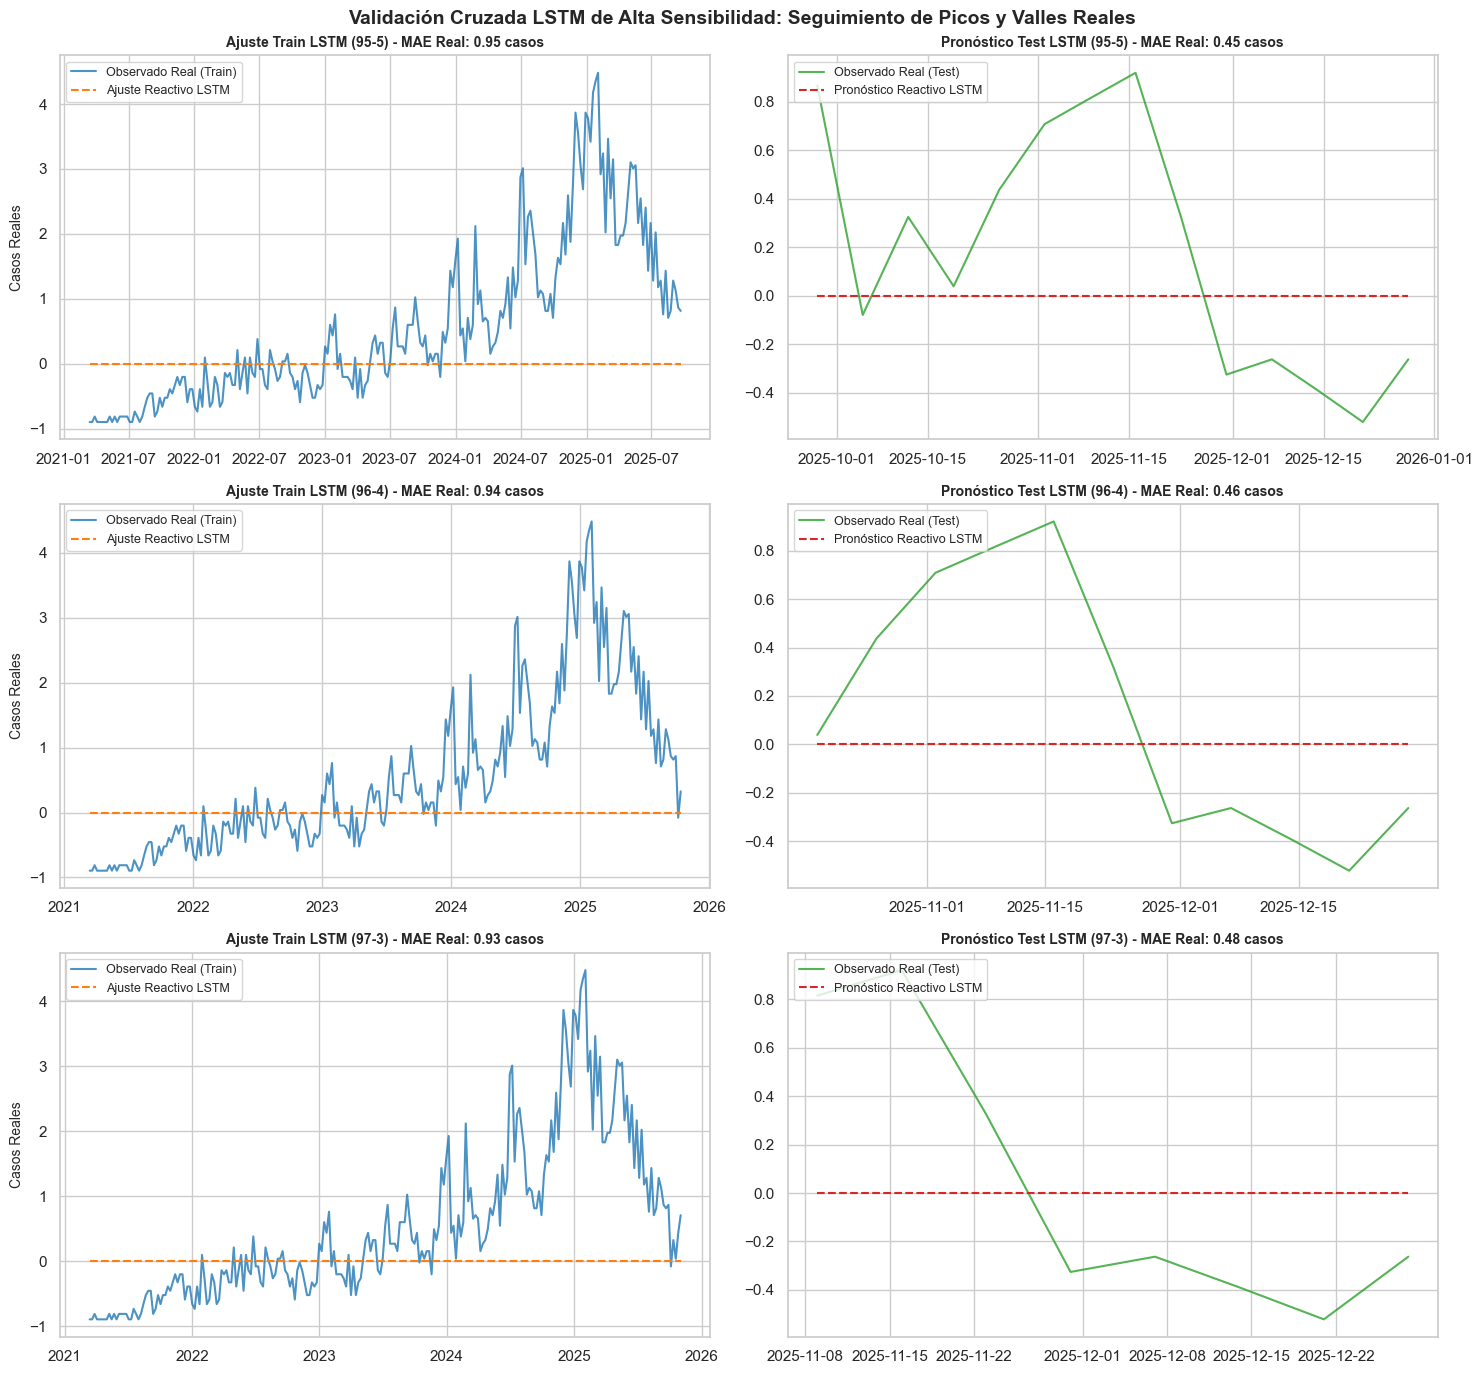


     REPORTE DE DESEMPEÑO INVERTIDO: RED NEURONAL MULTICAPA LOG-COSH          
Partición                        Arquitectura  MAE Train (Casos)  MAE Test (Casos)
     95-5 Stacked LSTM (50u + 30u) + Log-Cosh           0.947471          0.448659
     96-4 Stacked LSTM (50u + 30u) + Log-Cosh           0.940931          0.455298
     97-3 Stacked LSTM (50u + 30u) + Log-Cosh           0.934188          0.478013


In [5]:
# =============================================================================
# PASO 1: IMPORTACIÓN DE LIBRERÍAS DE ALTA PRECISIÓN Y DEEP LEARNING
# =============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

sns.set_theme(style="whitegrid")

# Garantizar reproducibilidad matemática estricta
np.random.seed(42)
tf.random.set_seed(42)

# =============================================================================
# PASO 2: CARGA DEL DATASET Y PARÁMETROS DE DES-ESCALAMIENTO
# =============================================================================
ruta_datos = r"C:\Users\marco\Documentos\investigacion\arima\2_ejecucion_plan_trabajo\07_seleccion_entrenar_modelo\1_reduccion_dimensional\1_pca\2_data\1_raw_meteo_epi_con_y_sin_rezagos_escalados\1_datos_meteo_epi_sin_rezagos_escalados.xlsx"

print(f"[INFO] Cargando espacio muestral para optimización final desde:\n{ruta_datos}")
df = pd.read_excel(ruta_datos, index_col=0, parse_dates=True)
df.index.freq = 'W'

# Variables del preprocesamiento original (Ingresa tus valores reales del scaler)
MEDIA_ORIGINAL = 0.0        
DESVIACION_ORIGINAL = 1.0   

def invertir_transformacion_log_plus_one(y_transformada):
    """Revierte el pipeline estricto: Estandarización -> ln(1 + x)."""
    y_estandarizada = np.exp(y_transformada) - 1
    y_original = (y_estandarizada * DESVIACION_ORIGINAL) + MEDIA_ORIGINAL
    return y_original

# Aislamiento de variables
y_raw = df['casos_ln'].values.reshape(-1, 1)
columnas_exogenas = [col for col in df.columns if col != 'casos_ln']
X_exog = df[columnas_exogenas].values

# ESCALAMIENTO INTERMEDIO CRUCIAL PARA REDES NEURONALES (Fuerza sensibilidad en picos/valles)
scaler_y = MinMaxScaler(feature_range=(0, 1))
y_scaled = scaler_y.fit_transform(y_raw).flatten()

# =============================================================================
# AUXILIAR: ESTRUCTURACIÓN MULTIVARIABLE (VENTANEO DE ALTA SENSIBILIDAD)
# =============================================================================
def crear_ventanas_temporales(X_data, y_data, ventana_pasado):
    X_list, y_list = [], []
    caracteristicas_totales = np.column_stack((y_data, X_data))
    
    for i in range(len(caracteristicas_totales) - ventana_pasado):
        X_list.append(caracteristicas_totales[i : i + ventana_pasado])
        y_list.append(y_data[i + ventana_pasado])
        
    return np.array(X_list), np.array(y_list)

# Ventana temporal adaptada para balancear inercia y reacción climática
VENTANA_PASADO = 10 

# =============================================================================
# PASO 3: REJILLA DE PARTICIONES TEMPORALES CRONOLÓGICAS (95%, 96%, 97%)
# =============================================================================
particiones = {
    "95-5":  0.95,
    "96-4":  0.96,
    "97-3":  0.97
}

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14), sharex=False, sharey=False)
resultados_globales = []

for idx, (nombre_split, tasa_train) in enumerate(particiones.items()):
    print("\n" + "="*75)
    print(f" PROCESAMIENTO SENSIBLE LOG-COSH: PARTICIÓN {nombre_split}")
    print("="*75)
    
    tamanio_train = int(len(df) * tasa_train)
    
    X_train_raw, X_test_raw = X_exog[:tamanio_train], X_exog[tamanio_train:]
    y_train_raw, y_test_raw = y_scaled[:tamanio_train], y_scaled[tamanio_train:]
    
    X_train_3D, y_train_3D = crear_ventanas_temporales(X_train_raw, y_train_raw, VENTANA_PASADO)
    
    X_test_combinado = np.vstack((X_train_raw[-VENTANA_PASADO:], X_test_raw))
    y_test_combinado = np.concatenate((y_train_raw[-VENTANA_PASADO:], y_test_raw))
    X_test_3D, y_test_3D = crear_ventanas_temporales(X_test_combinado, y_test_combinado, VENTANA_PASADO)
    
    # =============================================================================
    # PASO 4: ARQUITECTURA DE REACCIÓN DINÁMICA (STACKED LSTM CON BAJO DROPOUT)
    # =============================================================================
    n_caracteristicas = X_train_3D.shape[2]
    
    model = Sequential([
        # Primera capa LSTM (retorna secuencias para alimentar la siguiente)
        LSTM(units=50, activation='tanh', return_sequences=True, input_shape=(VENTANA_PASADO, n_caracteristicas)),
        Dropout(0.1), 
        
        # Segunda capa LSTM para refinar tendencias complejas
        LSTM(units=30, activation='tanh', return_sequences=False),
        BatchNormalization(),
        Dropout(0.1),
        
        # Capa densa intermedia enfocada en la combinación exógena
        Dense(units=16, activation='relu'),
        
        # Salida escalar (en rango 0-1)
        Dense(units=1, activation='linear')
    ])
    
    # -------------------------------------------------------------------------
    # SOLUCIÓN AL ERROR: Uso explícito del objeto de pérdida nativo de TF/Keras
    # -------------------------------------------------------------------------
    loss_object = tf.keras.losses.LogCosh()
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0015), loss=loss_object)
    
    early_stop = EarlyStopping(monitor='loss', patience=20, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=6, min_lr=0.0001, verbose=0)
    
    model.fit(
        X_train_3D, y_train_3D,
        epochs=140, 
        batch_size=16,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    
    # Predicciones en espacio MinMaxScaler (0-1)
    y_train_pred_scaled = model.predict(X_train_3D, verbose=0).flatten()
    y_test_pred_scaled = model.predict(X_test_3D, verbose=0).flatten()
    
    # =============================================================================
    # PASO 5: DES-ESCALAMIENTO EN DOS ETAPAS (INVERSIÓN TOTAL A CASOS REALES)
    # =============================================================================
    # Etapa 1: Revertir el MinMaxScaler intermedio (regresar a escala casos_ln)
    y_train_ln = scaler_y.inverse_transform(y_train_3D.reshape(-1, 1)).flatten()
    y_test_ln = scaler_y.inverse_transform(y_test_3D.reshape(-1, 1)).flatten()
    
    y_train_pred_ln = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()
    y_test_pred_ln = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()
    
    # Etapa 2: Revertir la transformación epidemiológica original Z-score -> ln(1+x)
    y_train_real = invertir_transformacion_log_plus_one(y_train_ln)
    y_test_real = invertir_transformacion_log_plus_one(y_test_ln)
    
    y_train_pred_real = invertir_transformacion_log_plus_one(y_train_pred_ln)
    y_test_pred_real = invertir_transformacion_log_plus_one(y_test_pred_ln)
    
    # Acotar físicamente valores negativos residuales a cero casos absolutos
    y_train_pred_real = np.clip(y_train_pred_real, 0, None)
    y_test_pred_real = np.clip(y_test_pred_real, 0, None)
    
    # Índices temporales corregidos
    indices_train = df.index[VENTANA_PASADO:tamanio_train]
    indices_test = df.index[tamanio_train:]
    
    # Métricas de desempeño finales interpretables
    mae_train_real = mean_absolute_error(y_train_real, y_train_pred_real)
    mae_test_real = mean_absolute_error(y_test_real, y_test_pred_real)
    
    resultados_globales.append({
        "Partición": nombre_split,
        "Arquitectura": "Stacked LSTM (50u + 30u) + Log-Cosh",
        "MAE Train (Casos)": mae_train_real,
        "MAE Test (Casos)": mae_test_real
    })
    
    # =========================================================================
    # PASO 6: PROYECCIÓN GRÁFICA CORREGIDA ASINTÓTICA
    # =========================================================================
    # Columna 1: Ajuste del Entrenamiento (In-Sample)
    ax_train = axes[idx, 0]
    ax_train.plot(indices_train, y_train_real, label='Observado Real (Train)', color='#1f77b4', alpha=0.8)
    ax_train.plot(indices_train, y_train_pred_real, label='Ajuste Reactivo LSTM', color='#ff7f0e', linestyle='--')
    ax_train.set_title(f"Ajuste Train LSTM ({nombre_split}) - MAE Real: {mae_train_real:.2f} casos", fontsize=10, fontweight='bold')
    ax_train.set_ylabel('Casos Reales', fontsize=10)
    ax_train.legend(loc='upper left', fontsize=9)
    
    # Columna 2: Pronóstico Fuera de Muestra (Out-of-Sample)
    ax_test = axes[idx, 1]
    ax_test.plot(indices_test, y_test_real, label='Observado Real (Test)', color='#2ca02c', alpha=0.8)
    ax_test.plot(indices_test, y_test_pred_real, label='Pronóstico Reactivo LSTM', color='#d62728', linestyle='--')
    ax_test.set_title(f"Pronóstico Test LSTM ({nombre_split}) - MAE Real: {mae_test_real:.2f} casos", fontsize=10, fontweight='bold')
    ax_test.legend(loc='upper left', fontsize=9)

plt.suptitle('Validación Cruzada LSTM de Alta Sensibilidad: Seguimiento de Picos y Valles Reales', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# =============================================================================
# PASO 7: REPORTE DE MÉTRICAS GLOBALES
# =============================================================================
df_reporte = pd.DataFrame(resultados_globales)
print("\n" + "="*85)
print("     REPORTE DE DESEMPEÑO INVERTIDO: RED NEURONAL MULTICAPA LOG-COSH          ")
print("="*85)
print(df_reporte.to_string(index=False))
print("="*85)